In [ ]:
# 1. Força a exclusão da pasta antiga para evitar conflitos se rodar de novo
!rm -rf dados_brutos

!mkdir dados_brutos
!mkdir dados_brutos/normal
!mkdir dados_brutos/imbalance
!mkdir dados_brutos/horizontal-misalignment
!mkdir dados_brutos/vertical-misalignment
!mkdir dados_brutos/overhang
!mkdir dados_brutos/underhang

print("Baixando os datasets da UFRJ...")
!wget -q -O normal.zip "https://www02.smt.ufrj.br/~offshore/mfs/database/mafaulda/normal.zip"
!wget -q -O imbalance.zip "https://www02.smt.ufrj.br/~offshore/mfs/database/mafaulda/imbalance.zip"
!wget -q -O overhang.zip "https://www02.smt.ufrj.br/~offshore/mfs/database/mafaulda/overhang.zip"
!wget -q -O underhang.zip "https://www02.smt.ufrj.br/~offshore/mfs/database/mafaulda/underhang.zip"
!wget -q -O horizontal.zip "https://www02.smt.ufrj.br/~offshore/mfs/database/mafaulda/horizontal-misalignment.zip"
!wget -q -O vertical.zip "https://www02.smt.ufrj.br/~offshore/mfs/database/mafaulda/vertical-misalignment.zip"

print("Extraindo os arquivos...")
!unzip -q -o normal.zip -d dados_brutos/normal
!unzip -q -o imbalance.zip -d dados_brutos/imbalance
!unzip -q -o overhang.zip -d dados_brutos/overhang
!unzip -q -o underhang.zip -d dados_brutos/underhang

!unzip -q -o horizontal.zip -d dados_brutos/horizontal-misalignment
!unzip -q -o vertical.zip -d dados_brutos/vertical-misalignment

print("Limpando arquivos .zip temporários...")
!rm normal.zip imbalance.zip horizontal.zip vertical.zip overhang.zip underhang.zip

print("✅ Todos os dados baixados e organizados!")

Baixando os datasets da UFRJ...
Extraindo os arquivos...
Limpando arquivos .zip temporários...
✅ Todos os dados baixados e organizados!


# 1. Configurações Físicas e Bibliotecas
Antes de qualquer extração matemática, precisamos definir as leis da física que regem o nosso sistema de aquisição.
O dataset MAFAULDA utiliza acelerômetros industriais padronizados.

* **Taxa de Amostragem (51.200 Hz):** Segue a regra do filtro anti-aliasing da norma ISO ($F_s = F_{max} \times 2.56$). Isso nos permite escutar o rolamento com perfeição até frequências de 20.000 Hz.
* **Janela Matemática (8192 pontos):** Para a Transformada de Fourier (FFT) ser computacionalmente rápida, o tamanho da amostra deve ser uma potência de 2. Com 8192 pontos, a cad[texto do link](https://)a 0,16 segundos o sistema tira uma "foto" completa de múltiplas voltas do eixo do motor.

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew
from scipy.fft import fft, fftfreq
import scipy.signal as signal
from scipy.signal import butter, filtfilt, hilbert

# ---------------------------------------------------------
# 1. PARÂMETROS FÍSICOS DO SISTEMA (ADAPTADO PARA O EDGE)
# ---------------------------------------------------------

# Mantemos 51.2kHz porque é a realidade física de como o .csv foi gravado
TAXA_AMOSTRAGEM = 51200

# Mantemos 8192 para garantir uma resolução de 6.25Hz (Muito similar aos 3.12Hz do ESP32)
TAMANHO_JANELA = 8192

# O SEGREDO DO HARDWARE: A Conversão Volt -> Força G
# O sensor do MAFAULDA gera 100 milivolts para cada 1 'g' de aceleração.
# O nosso ADXL345 no C++ já gera o dado nativamente em 'g'.
# Precisamos desta constante para traduzir o MAFAULDA para a "língua" do ESP32.
SENSIBILIDADE_V_G = 0.100
GRAVIDADE = 9.80665
REF_MIC = 1.0

COLUNAS = ['tachometer', 'uh_ax', 'uh_rad', 'uh_tan', 'oh_ax', 'oh_rad', 'oh_tan', 'microphone']

dataset_ia = []
dataset_humano = []

print("✅ Bibliotecas e Fundações Físicas configuradas.")
print("⚠️ Atenção: A conversão Volt -> G será aplicada para calibrar a IA com o ADXL345.")

✅ Bibliotecas e Fundações Físicas configuradas.
⚠️ Atenção: A conversão Volt -> G será aplicada para calibrar a IA com o ADXL345.


# 2. Domínio da Frequência (FFT)
Analisar a onda de vibração crua é como tentar entender uma sinfonia olhando para a vibração do cone do alto-falante. A **Transformada Rápida de Fourier (FFT)** separa essa sinfonia nos seus instrumentos individuais (frequências).
Agrupamos essas frequências em "bandas" (gavetas) estratégicas. Desbalanceamento grita nas baixas frequências (abaixo de 100 Hz), enquanto o atrito metálico grita nas altas (acima de 2000 Hz).

In [ ]:
# ---------------------------------------------------------
# 2. ENGENHARIA DE FEATURES: BANDAS DE FREQUÊNCIA
# ---------------------------------------------------------
def obter_features_espectrais(yf_pos, xf_pos, prefixo_eixo):
    features = {}

    # [FONTE: Manuais da SKF e Norma ISO 10816-3 para Análise de Espectro]
    # Dividimos o eixo X (Hertz) em fatias.
    # 0 a 200 Hz: Região de baixa frequência (1X, 2X, 3X a rotação do motor).
    # Aqui procuramos Desbalanceamento e Desalinhamento.
    # 2000 a 10000 Hz: Região de alta frequência. Aqui moram os cliques e atritos de metal
    # (Falhas de gaiola, esferas e pistas de rolamento).
    limites_bandas = [
        (0, 50), (50, 100), (100, 200),
        (200, 400), (400, 800), (800, 1500),
        (1500, 3000), (3000, 5000), (5000, 10000)
    ]

    # O Python "desempacota" os pares aqui automaticamente a cada volta do loop
    for limite_inf, limite_sup in limites_bandas:

        # Cria uma máscara (um filtro) pegando apenas os Hertz que estão dentro desta gaveta
        mascara = (xf_pos >= limite_inf) & (xf_pos < limite_sup)
        nome_banda = f"{prefixo_eixo}_b_{limite_inf}_{limite_sup}"

        if np.any(mascara):
            # Energia (Soma): Mostra o atrito generalizado daquela banda
            features[f'{nome_banda}_energia'] = np.sum(yf_pos[mascara])
            # Pico (Max): Encontra a agulha no palheiro (uma ressonância muito forte e isolada)
            features[f'{nome_banda}_pico'] = np.max(yf_pos[mascara])
        else:
            features[f'{nome_banda}_energia'] = 0.0
            features[f'{nome_banda}_pico'] = 0.0

    return features

print("✅ Extrator de Bandas FFT pronto.")

✅ Extrator de Bandas FFT pronto.


# 3. Análise de Envelope (A Matemática do Rolamento)
A falha em um rolamento (como uma rachadura na pista externa) não gera uma vibração constante. Ela gera **micro-impactos (cliques)** sempre que uma esfera passa pela rachadura. Como esses impactos são incrivelmente rápidos, a energia deles se perde no domínio da frequência normal.

Para extrair esses cliques, usamos a **Técnica de Demodulação (Envelope)**, que funciona em três etapas matemáticas severas:

**Passo 1: Filtro Passa-Alta (High-Pass)**
Removemos todas as frequências baixas (rotação do eixo, desalinhamentos) para isolar apenas o ruído de alta frequência (ressonância do metal) onde o "clique" do impacto ocorre.

**Passo 2: A Transformada de Hilbert**
Aqui entra a mágica. Dado o sinal filtrado $x(t)$, a Transformada de Hilbert $\mathcal{H}\{x(t)\}$ desloca a fase de todas as frequências em exatos 90 graus ($\pi/2$). Com isso, construímos o "Sinal Analítico" complexo $Z(t)$:

$$Z(t) = x(t) + j \cdot \mathcal{H}\{x(t)\}$$

O *Envelope* $E(t)$ do sinal é simplesmente a magnitude (o módulo) desse número complexo em cada instante de tempo. Ele traça uma linha imaginária conectando apenas os picos dos impactos metálicos:

$$E(t) = \sqrt{x(t)^2 + \mathcal{H}\{x(t)\}^2}$$

**Passo 3: A FFT do Envelope**
Ao aplicar a Transformada de Fourier em cima desse Envelope $E(t)$, nós descobrimos **quantas vezes por segundo** o impacto está ocorrendo (a Frequência de Defeito do Rolamento).

In [ ]:
# ---------------------------------------------------------
# 3. ENGENHARIA DE FEATURES: ANÁLISE DE ENVELOPE
# ---------------------------------------------------------
def extrair_picos_envelope(sinal_array):

    # --- 1. FILTRO PASSA-ALTA (High-Pass) ---
    # [FONTE: Manuais de Análise de Vibração - Técnicas de Demodulação de Amplitude]
    # O que faz: Cortamos frequências baixas para não confundir a rotação maciça do eixo com o impacto minúsculo do rolamento.
    # Matemática: O Teorema de Nyquist diz que a frequência máxima legível é metade da taxa de amostragem.
    # Exemplo: O motor gira fazendo barulho em 30 Hz. O filtro bloqueia tudo abaixo de 2000 Hz. O barulho de 30 Hz desaparece, sobrando apenas as altas frequências de ressonância do metal rachando.
    nyquist = 0.5 * TAXA_AMOSTRAGEM
    corte_normalizado = 2000.0 / nyquist
    b, a = butter(4, corte_normalizado, btype='high')
    sinal_filtrado = filtfilt(b, a, sinal_array)

    # --- 2. RETIFICAÇÃO E ENVELOPE ---
    # [FONTE: Processamento de Sinais Digitais (DSP) - Scipy Signal API]
    # O que faz: A Transformada de Hilbert cria um sinal matemático complexo cuja magnitude (valor absoluto) revela o "contorno" da onda de impacto.
    # Exemplo: Imagine uma cerca cheia de estacas pontiagudas (os impactos de alta frequência). A Transformada de Hilbert é como jogar um lençol por cima da cerca: ela traça uma linha suave conectando apenas os topos das estacas.
    sinal_analitico = hilbert(sinal_filtrado)
    envelope = np.abs(sinal_analitico)

    # --- 3. FFT DO ENVELOPE ---
    # [FONTE: Matemática Espectral de Fourier]
    # O que faz: Pega o "lençol" (envelope) criado no passo anterior e procura um padrão de repetição dentro dele.
    # Exemplo: Se a esfera do rolamento bate na rachadura 4 vezes a cada volta do eixo, e o eixo dá 30 voltas por segundo, a FFT vai mostrar um pico gigantesco exatamente na Frequência de Falha de 120 Hz (30 * 4).
    yf_env = np.abs(fft(envelope))
    xf_env = fftfreq(TAMANHO_JANELA, 1 / TAXA_AMOSTRAGEM)

    # A FFT sempre gera uma imagem espelhada (positiva e negativa). Usamos só a metade útil.
    yf_env_pos = yf_env[:TAMANHO_JANELA//2]
    xf_env_pos = xf_env[:TAMANHO_JANELA//2]

    # [FONTE: Eletrônica Analógica]
    # A frequência 0 Hz representa o nível DC (Corrente Contínua) do sinal, não uma vibração real.
    # Por isso, nós a zeramos para ela não ofuscar os picos reais.
    yf_env_pos[0] = 0

    # --- 4. EXTRAÇÃO DAS FEATURES PARA A IA ---
    # [FONTE: Catálogo de Frequências Cinemáticas de Defeito (BPFI, BPFO, BSF, FTF)]
    # O que faz: As falhas geram picos específicos de energia. Nós pegamos as coordenadas (Frequência e Amplitude) onde a energia foi mais agressiva.
    # Exemplo: O algoritmo ordena os resultados e nos devolve: "O pior impacto foi na frequência 120 Hz, com amplitude de 0.05 V".

    # Pegamos os 2 maiores picos ([-2:] pega os últimos da fila crescente, e o [::-1] inverte a ordem para o maior ficar em primeiro)
    indices_top = np.argsort(yf_env_pos)[-2:][::-1]

    # Arredondamos os números para aliviar a base de dados
    freqs = np.round(xf_env_pos[indices_top], 2)
    amps = np.round(yf_env_pos[indices_top] / (TAMANHO_JANELA//2), 4)

    return freqs, amps

print("✅ Extrator de Envelope Demodulado pronto e documentado.")

✅ Extrator de Envelope Demodulado pronto e documentado.


# 4. O Gerador Mestre (Processamento Multidomínio)
Esta é a função central do nosso motor de extração. Ela pega a "janela" de dados crus (8192 linhas de tensão elétrica lida pelos sensores) e processa sob duas óticas completamente diferentes: **A visão da Máquina (Otimizada)** e a **Visão do Humano (Física)**.

### Parte A: O Cérebro da IA (Física Crua)
Modelos de Machine Learning (como o XGBoost) são algoritmos de proporção matemática; eles não se importam se o número é $0.5 \text{ Volts}$ ou $4.9 \text{ m/s}^2$. Para **poupar processamento no microcontrolador** na fábrica, nós não convertemos as unidades da IA. O ESP32 vai ler o Volt cru no pino e jogar na IA.
* **RMS (Root Mean Square):** Mede a energia contínua e destrutiva global do eixo.
* **Curtose (Kurtosis):** Mede o "peso das caudas" da estatística. Um valor maior que 3 significa que estão ocorrendo impactos violentos (como engrenagens batendo).
* **Assimetria (Skewness):** Mede se o eixo está vibrando mais para um lado do que para o outro (típico de desalinhamento ou eixos empenados).


### Parte B: O Painel Humano (Física Traduzida)
O Engenheiro de Confiabilidade que estiver olhando o dashboard SaaS precisa de dados palpáveis e normatizados. Aqui nós traduzimos os sinais elétricos para o mundo real:
* **Tacômetro para RPM:** O sensor óptico manda um pulso de 5V por volta. Usamos a FFT para encontrar a frequência exata (Hz) desses pulsos elétricos e multiplicamos por 60 para obter a RPM verdadeira.
* **Microfone para Decibéis (dB):** Aplicamos o logaritmo na tensão acústica $20 \log_{10}(\text{Pressão} / \text{Ref})$ para imitar como o ouvido humano percebe o volume do atrito.
* **Volts para Aceleração ($m/s^2$):** Dividimos a voltagem lida pela sensibilidade do sensor ($0.1 \text{ V/g}$) e multiplicamos pela gravidade da Terra ($9.80665 \text{ m/s}^2$).

### Parte C: Montagem dos Datasets
Por fim, injetamos todas as dezenas de colunas em dois dicionários independentes. O dicionário da IA vai guardar os dados crus dos eixos Dianteiro (Overhang) e Traseiro (Underhang) em formato numérico puro, enquanto o dicionário humano vai guardar um resumo amigável e já arredondado para exibição nos gráficos.

In [ ]:
# ---------------------------------------------------------
# 4. O ESPELHO DIGITAL (GERA EXATAMENTE AS 36 FEATURES DO C++)
# ---------------------------------------------------------
def mastigar_dados_god_payload(caminho_arquivo, label_defeito):
    df_bruto = pd.read_csv(caminho_arquivo, header=None, names=COLUNAS)

    # Função interna idêntica ao "extrair_features_vib" do C++
    def extrair_vib_cplusplus(sinal_g):
        rms = np.sqrt(np.mean(sinal_g**2))
        kurt = kurtosis(sinal_g, fisher=False)
        skew_val = skew(sinal_g, bias=False)

        yf = np.abs(fft(sinal_g))
        xf = fftfreq(TAMANHO_JANELA, 1 / TAXA_AMOSTRAGEM)

        mag = yf[:TAMANHO_JANELA//2] / TAMANHO_JANELA
        energia = mag * mag
        freqs = xf[:TAMANHO_JANELA//2]

        e_b1, p_b1, e_b2, e_b3, e_b4 = 0.0, 0.0, 0.0, 0.0, 0.0

        for i in range(1, len(freqs)):
            f = freqs[i]
            eng = energia[i]
            m = mag[i]

            if f <= 60.0:
                e_b1 += eng
                if m > p_b1: p_b1 = m
            elif f <= 150.0:
                e_b2 += eng
            elif f <= 500.0:
                e_b3 += eng
            else:
                e_b4 += eng

        return [rms, kurt, skew_val, e_b1, p_b1, e_b2, e_b3, e_b4]

    for inicio in range(0, len(df_bruto) - TAMANHO_JANELA, TAMANHO_JANELA):
        janela = df_bruto.iloc[inicio : inicio + TAMANHO_JANELA]

        # Conversão Volt -> Força G
        sinal_z = janela['oh_ax'].values / SENSIBILIDADE_V_G  # Eixo Z = Axial
        sinal_y = janela['oh_tan'].values / SENSIBILIDADE_V_G # Eixo Y = Tangencial
        sinal_x = janela['oh_rad'].values / SENSIBILIDADE_V_G # Eixo X = Radial
        sinal_mic = janela['microphone'].values

        # 1. Extração de Vibração (3 eixos * 8 features = 24 features)
        feat_z = extrair_vib_cplusplus(sinal_z)
        feat_y = extrair_vib_cplusplus(sinal_y)
        feat_x = extrair_vib_cplusplus(sinal_x)

        # 2. Extração do Microfone idêntica ao C++ (12 features)
        mic_rms = np.sqrt(np.mean(sinal_mic**2))
        mic_pico = np.max(np.abs(sinal_mic))
        mic_crista = mic_pico / mic_rms if mic_rms > 0 else 0

        yf_mic = np.abs(fft(sinal_mic))
        xf_mic = fftfreq(TAMANHO_JANELA, 1 / TAXA_AMOSTRAGEM)
        mag_mic = yf_mic[:TAMANHO_JANELA//2] / TAMANHO_JANELA
        eng_mic = mag_mic * mag_mic
        freqs_mic = xf_mic[:TAMANHO_JANELA//2]

        e = [0.0]*5
        p = [0.0]*5

        for i in range(1, len(freqs_mic)):
            f = freqs_mic[i]
            eng = eng_mic[i]
            m = mag_mic[i]

            b = -1
            if f <= 500: b = 0
            elif f <= 2000: b = 1
            elif f <= 5000: b = 2
            elif f <= 10000: b = 3
            else: b = 4

            if b != -1:
                e[b] += eng
                if m > p[b]: p[b] = m

        feat_mic = [mic_rms, mic_crista]
        for i in range(5):
            feat_mic.append(e[i])
            feat_mic.append(p[i])

        # Junta tudo no Array Final (Exatas 36 posições)
        features_totais = feat_z + feat_y + feat_x + feat_mic

        # =========================================================
        # PARTE C: SALVANDO NOS BANCOS
        # =========================================================

        # Cria chaves numéricas de 0 a 35 para garantir compatibilidade
        linha_ia = {f'feat_{i}': features_totais[i] for i in range(36)}
        linha_ia['label_original'] = label_defeito
        linha_ia['arquivo_origem'] = caminho_arquivo
        dataset_ia.append(linha_ia)

        # Dashboard Humano (Simplificado)
        linha_humana = {
            'Diagnostico_Real': label_defeito,
            'Acustica_dB': np.round(20 * np.log10((mic_rms + 1e-12) / REF_MIC), 1),
            'Eixo_Z_ms2': np.round(feat_z[0] * GRAVIDADE, 2),
            'Eixo_Y_ms2': np.round(feat_y[0] * GRAVIDADE, 2),
            'Eixo_X_ms2': np.round(feat_x[0] * GRAVIDADE, 2),
            'Arquivo': caminho_arquivo
        }
        dataset_humano.append(linha_humana)

print("✅ Espelho C++ criado! O Python vai gerar EXATAS 36 features.")

✅ Espelho C++ criado! O Python vai gerar EXATAS 36 features.


# 5. O Operário Braçal (Varredura, Extração e Exportação)
Nesta etapa final, saímos da matemática e entramos na **Engenharia de Dados**. Nós precisamos aplicar todas as funções complexas que criamos acima aos mais de 1000 arquivos do dataset MAFAULDA, de forma automática.

**1. O Dicionário de Defeitos (Gabarito):**
Machine Learning supervisionado precisa de um gabarito. Criamos o `MAPA_DEFEITOS`, que diz à máquina o que cada pasta significa. Se o arquivo vem da pasta `imbalance`, a IA anota o número `1`. Se vem de `normal`, anota `0`.

**2. A Busca Recursiva (Glob):**
Usamos a biblioteca `glob` para agir como um "cão farejador". Comandos como `**/*.csv` dizem ao Python para entrar em todas as subpastas que existirem e puxar todos os arquivos Excel.

**3. O Nascimento das Duas Bases de Dados:**
A cada arquivo encontrado, a função mestre `mastigar_dados_god_payload` roda. Ela envia os dados crus em **Volts** para a tabela da Inteligência Artificial e envia os dados mastigados em **Física (m/s² e dB)** para a tabela Humana.

Por fim, usamos a biblioteca `pandas` para compilar tudo em formato de tabela de banco de dados e salvamos os dois arquivos `.csv` finais no disco rígido.

In [ ]:
# ---------------------------------------------------------
# 5. EXECUÇÃO E SALVAMENTO DOS BANCOS DE DADOS
# ---------------------------------------------------------

# [FONTE: Metadados do Dataset MAFAULDA (UFRJ)]
# Removidos os defeitos "underhang", pois o nosso hardware físico (ESP32-S3)
# possui apenas 1 sensor de vibração focado no mancal principal (overhang) + 1 microfone.
MAPA_DEFEITOS = {
    "normal": 0,
    "imbalance": 1,
}

print("Iniciando varredura dupla (Extrator IA + Extrator Humano)...")
print("⚠️ Isso pode demorar alguns minutos. Pegue um café! ☕")

caminho_base = 'dados_brutos'

# Loop 1: Passamos por cada defeito listado no dicionário acima
for pasta_chave, label_id in MAPA_DEFEITOS.items():

    # Procura todos os arquivos CSV dentro das pastas mapeadas
    padrao_busca = os.path.join(caminho_base, '**', pasta_chave, '**', '*.csv')
    arquivos_encontrados = glob.glob(padrao_busca, recursive=True)

    if len(arquivos_encontrados) > 0:
        print(f"-> Analisando {len(arquivos_encontrados)} arquivos da classe: {pasta_chave}")

        # Loop 2: Abre arquivo por arquivo e joga no nosso "Liquidificador" (Célula 4)
        for caminho in arquivos_encontrados:
            mastigar_dados_god_payload(caminho, label_id)

# ---------------------------------------------------------
# FINALIZAÇÃO: SALVANDO NO DISCO
# ---------------------------------------------------------

# 1. Transformamos a nossa lista de dicionários da IA em uma Tabela estruturada
df_ia = pd.DataFrame(dataset_ia)
# Atualizamos o nome do arquivo para refletir a nova arquitetura de Hardware
df_ia.to_csv('dataset_ia_hardware_real.csv', index=False)

# 2. Transformamos a nossa lista de dicionários Humanos em outra Tabela
df_humano = pd.DataFrame(dataset_humano)
# Atualizamos o nome para o Dashboard Laravel
df_humano.to_csv('dataset_dashboard_hardware_real.csv', index=False)

print("\n🎉 TRABALHO CONCLUÍDO COM SUCESSO ABSOLUTO!")
print(f"🧠 Dataset IA (Volts Puros): {len(df_ia)} linhas e {len(df_ia.columns)} colunas.")
print(f"👨‍💻 Dataset Humano (m/s² e dB): {len(df_humano)} linhas e {len(df_humano.columns)} colunas.")

Iniciando varredura dupla (Extrator IA + Extrator Humano)...
⚠️ Isso pode demorar alguns minutos. Pegue um café! ☕
-> Analisando 98 arquivos da classe: normal
-> Analisando 666 arquivos da classe: imbalance

🎉 TRABALHO CONCLUÍDO COM SUCESSO ABSOLUTO!
🧠 Dataset IA (Volts Puros): 22920 linhas e 38 colunas.
👨‍💻 Dataset Humano (m/s² e dB): 22920 linhas e 6 colunas.


# 6. Geração de Imagens (A Visão Computacional)

Até agora, preparamos os dados numéricos (Volts e $m/s^2$) para o nosso futuro algoritmo. Mas para construir uma IA Multimodal, precisamos que a máquina também "veja" o som do motor. Para isso, usamos o **Espectrograma de Mel (Mel-Spectrogram)**.

**O que é um Espectrograma?**
* **Onda no Tempo (Audio):** Mostra apenas a amplitude (volume) subindo e descendo.
* **Espectrograma (Imagem):** Transforma o som em um mapa de calor 2D.
    * O Eixo X é o tempo.
    * O Eixo Y é a frequência (Hz).
    * A Cor (Brilho) é a intensidade (dB).
Ele nos mostra "quando" e "com qual força" cada ruído metálico ocorreu.

**A Escala de Mel:**
A escala de Mel "espreme" matematicamente as altas frequências e estica as baixas, imitando a forma como o ouvido humano e a física de propagação acústica funcionam. Essa imagem é perfeita para treinar Redes Neurais Convolucionais (CNNs).

### Passo 1: Preparação e Limpeza
Antes de gerar as milhares de imagens, precisamos garantir que a pasta do Google Drive esteja limpa (para não misturar processamentos antigos) e carregar o nosso Dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
import shutil

# ---------------------------------------------------------
# 1. FAXINA DO DIRETÓRIO
# ---------------------------------------------------------
print("1. Faxina: Removendo os ZIPs viciados do Google Drive...")
# Define o caminho onde os arquivos finais serão salvos (seu Google Drive)
pasta_destino_drive = '/content/drive/MyDrive/Dataset_Metrologia_Multimodal'
os.makedirs(pasta_destino_drive, exist_ok=True)

# Busca e deleta todos os arquivos .zip antigos para evitar contaminação de dados
zips_antigos = glob.glob(os.path.join(pasta_destino_drive, '*.zip'))
for z in zips_antigos:
    os.remove(z)
print("✅ Limpeza concluída.")

1. Faxina: Removendo os ZIPs viciados do Google Drive...
✅ Limpeza concluída.


### Passo 2: O Embaralhamento Global (Shuffle)

Este é **o segredo do sucesso** de qualquer treinamento de Rede Neural que processa dados em lotes (batches).
Se não embaralharmos o nosso CSV Mestre, o sistema vai gerar o Lote 1 apenas com motores "Normais" e o Lote 2 apenas com motores "Desbalanceados". A IA vai aprender a decorar o lote (vício de memória) em vez de aprender a física do defeito.

Ao usarmos a função `.sample(frac=1)`, nós pegamos 100% das linhas do CSV que criamos na etapa anterior e as misturamos completamente, criando uma "salada de frutas" de defeitos perfeitos.

In [ ]:
# ---------------------------------------------------------
# 2. CARREGAMENTO E EMBARALHAMENTO (SHUFFLE)
# ---------------------------------------------------------
print("\n2. Carregando o Dataset Bruto e Aplicando Embaralhamento Global...")

# Carrega o CSV raiz (o banco de dados numérico que a IA vai usar)
# [Atenção] Se o seu arquivo anterior se chama dataset_ia_multieixos_v2.csv, atualize este nome!
df_completo = pd.read_csv('dataset_ia_multieixos_v2.csv')

# --- O SEGREDO DO SUCESSO: O SHUFFLE ---
# frac=1: Pega 100% da base. random_state=42: Garante que o embaralhamento será sempre igual toda vez que rodar.
df_completo = df_completo.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"✅ {len(df_completo)} linhas embaralhadas perfeitamente.")

# --- CONFIGURAÇÕES DO PROCESSAMENTO ---
TAMANHO_DO_LOTE = 20000     # Quebra o ZIP a cada 20 mil imagens para não estourar a memória RAM/Disco
TAXA_AMOSTRAGEM = 51200     # Padrão físico do motor (Fs)
TAMANHO_JANELA = 8192       # Nossa janela matemática
pasta_temp = '/content/temp_imagens' # Trabalhamos na máquina local do Colab (mais rápido que o Drive)

# Prepara a nova coluna que vai guardar o endereço da imagem gerada
if 'caminho_imagem' not in df_completo.columns:
    df_completo['caminho_imagem'] = ""


2. Carregando o Dataset Bruto e Aplicando Embaralhamento Global...
✅ 84930 linhas embaralhadas perfeitamente.


### Passo 3: Geração de Espectrogramas RGB (A Câmera Tripla)

Como o nosso hardware final usará um sensor MEMS Triaxial (ADXL345) posicionado na frente do motor, nós vamos explorar todo o seu potencial espacial.

Em vez de gerar uma imagem em escala de cinza de um único eixo, nós leremos os 3 eixos do Overhang (Axial, Radial e Tangencial) e criaremos 3 espectrogramas independentes.
Em seguida, usamos o `numpy.stack` para empilhar essas 3 imagens como se fossem as camadas **R (Red), G (Green) e B (Blue)** de uma foto colorida convencional.

* **Canal Vermelho (R):** Vibração Axial (Especialista em Desalinhamento).
* **Canal Verde (G):** Vibração Radial (Especialista em Desbalanceamento).
* **Canal Azul (B):** Vibração Tangencial (Especialista em Folgas e Torção).

Assim, a nossa Rede Neural (CNN) aprenderá a diagnosticar a máquina em 3D.

In [ ]:
# ---------------------------------------------------------
# 3. GERAÇÃO E COMPACTAÇÃO DOS LOTES MISTOS (RGB TRIAXIAL)
# ---------------------------------------------------------
print("\n3. Iniciando a Geração Fatiada dos Espectrogramas RGB (Eixos X, Y, Z)...")

total_amostras = len(df_completo)

# Quebra a execução em blocos do TAMANHO_DO_LOTE para não estourar a memória
for inicio_lote in range(0, total_amostras, TAMANHO_DO_LOTE):
    fim_lote = min(inicio_lote + TAMANHO_DO_LOTE, total_amostras)
    df_lote = df_completo.iloc[inicio_lote:fim_lote].copy()

    numero_lote = (inicio_lote // TAMANHO_DO_LOTE) + 1
    nome_zip = f'espectrogramas_RGB_lote_{numero_lote:03d}'
    caminho_zip_final = os.path.join(pasta_destino_drive, nome_zip + '.zip')

    print(f"\n--- Criando Lote Misto {numero_lote} (Linhas {inicio_lote} a {fim_lote}) ---")

    # Reseta a pasta temporária para o novo lote
    if os.path.exists(pasta_temp):
        shutil.rmtree(pasta_temp)
    os.makedirs(pasta_temp)

    # Varre a lista de amostras deste lote
    for index, row in df_lote.iterrows():
        caminho_csv_bruto = row['arquivo_origem']
        label = row['label_original']
        inicio_janela = int(row['inicio_janela'])

        # Cria as subpastas pelas classes (0 a 9) para organizar a CNN
        pasta_classe = os.path.join(pasta_temp, f'classe_{label}')
        os.makedirs(pasta_classe, exist_ok=True)

        # A "Chave Primária" da imagem para não perder o link com o CSV
        indice_real = df_lote.index.get_loc(index) + inicio_lote
        nome_imagem = f'img_rgb_{indice_real:07d}.png'
        caminho_imagem = os.path.join(pasta_classe, nome_imagem)

        try:
            # Lemos a janela exata de 8192 pontos do CSV bruto
            df_bruto = pd.read_csv(caminho_csv_bruto, header=None, skiprows=inicio_janela, nrows=TAMANHO_JANELA)

            # --- EXTRAÇÃO TRIAXIAL (OVERHANG) ---
            # Índices do MAFAULDA: 4 (oh_ax), 5 (oh_rad), 6 (oh_tan)
            sinal_ax = df_bruto.iloc[:, 4].values
            sinal_rad = df_bruto.iloc[:, 5].values
            sinal_tan = df_bruto.iloc[:, 6].values

            espectrogramas_db = []

            # Gera um espectrograma de Mel para cada eixo
            for sinal in [sinal_ax, sinal_rad, sinal_tan]:
                S = librosa.feature.melspectrogram(
                    y=sinal, sr=TAXA_AMOSTRAGEM, n_fft=TAMANHO_JANELA, hop_length=256, n_mels=64
                )
                # Converte para decibéis
                S_db = librosa.power_to_db(S, ref=np.max)

                # Normaliza a matriz do eixo para a escala de pixels (0 a 255)
                # Isso é crucial antes de empilhar como RGB
                S_db_norm = cv2.normalize(S_db, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
                espectrogramas_db.append(S_db_norm)

            # --- A FUSÃO RGB ---
            # Empilha: Axial (Red), Radial (Green), Tangencial (Blue)
            imagem_rgb = np.dstack((espectrogramas_db[0], espectrogramas_db[1], espectrogramas_db[2]))

            # Salva no disco (usamos cv2 porque plt.imsave embaraça canais de cores cruas)
            # O cv2 usa BGR por padrão, então invertemos a pilha para salvar como RGB real
            cv2.imwrite(caminho_imagem, cv2.cvtColor(imagem_rgb, cv2.COLOR_RGB2BGR))

            # Anota o endereço da imagem no dataframe Mestre
            df_completo.at[index, 'caminho_imagem'] = caminho_imagem

        except Exception as e:
            pass # Pula silenciosamente arquivos corrompidos da UFRJ

        if (indice_real + 1) % 5000 == 0:
            print(f"   -> {indice_real + 1} imagens RGB geradas...")

    # Terminou o lote? Compacta no Google Drive imediatamente
    print(f"Compactando o Lote Misto {numero_lote} para o Google Drive...")
    shutil.make_archive(os.path.join(pasta_destino_drive, nome_zip), 'zip', pasta_temp)

# ---------------------------------------------------------
# 4. SALVAMENTO DO NOVO MAPA MESTRE
# ---------------------------------------------------------
print("\n4. Salvando o CSV Mestre Embaralhado...")
# O Dataset final terá a indicação exata de onde achar cada imagem RGB
caminho_csv_mestre = os.path.join(pasta_destino_drive, 'dataset_mestre_rgb_embaralhado.csv')
df_completo.to_csv(caminho_csv_mestre, index=False)

print("\n✅ BANCO DE DADOS RGB FINALIZADO!")


3. Iniciando a Geração Fatiada dos Espectrogramas RGB (Eixos X, Y, Z)...

--- Criando Lote Misto 1 (Linhas 0 a 20000) ---
   -> 5000 imagens RGB geradas...
   -> 10000 imagens RGB geradas...
   -> 15000 imagens RGB geradas...
   -> 20000 imagens RGB geradas...
Compactando o Lote Misto 1 para o Google Drive...

--- Criando Lote Misto 2 (Linhas 20000 a 40000) ---
   -> 25000 imagens RGB geradas...
   -> 30000 imagens RGB geradas...
   -> 35000 imagens RGB geradas...
   -> 40000 imagens RGB geradas...
Compactando o Lote Misto 2 para o Google Drive...

--- Criando Lote Misto 3 (Linhas 40000 a 60000) ---
   -> 45000 imagens RGB geradas...
   -> 50000 imagens RGB geradas...
   -> 55000 imagens RGB geradas...
   -> 60000 imagens RGB geradas...
Compactando o Lote Misto 3 para o Google Drive...

--- Criando Lote Misto 4 (Linhas 60000 a 80000) ---
   -> 65000 imagens RGB geradas...
   -> 70000 imagens RGB geradas...
   -> 75000 imagens RGB geradas...
   -> 80000 imagens RGB geradas...
Compactan

# 7. Lente de Aumento (Como a IA "Enxerga" em 3D)

Para entender a nossa abordagem Triaxial, nós vamos "desmontar" a imagem que a nossa Rede Neural vai estudar.

Pegaremos uma amostra de **Desalinhamento Vertical (Classe 3)**.
O código abaixo lerá os 3 eixos simultaneamente, gerará 3 espectrogramas separados e, em seguida, os empilhará formando uma foto colorida `(R, G, B)`.

* Manchas **Vermelhas** puras indicam vibração exclusiva no eixo Axial.
* Manchas **Verdes** indicam socos no eixo Radial.
* Cores misturadas (como **Amarelo** ou **Ciano**) mostram como o defeito se propaga pelo corpo metálico do motor ao mesmo tempo![texto do link](https://)

Verificando os arquivos gerados no seu ambiente...

Linha do Dataset Tabular lida com sucesso!
Arquivo Bruto Vinculado: dados_brutos/normal/normal/43.6224.csv
Linha de Início da Janela: 0
Diagnóstico Alvo: Normal
RMS Radial Registrado: 0.0302 Volts


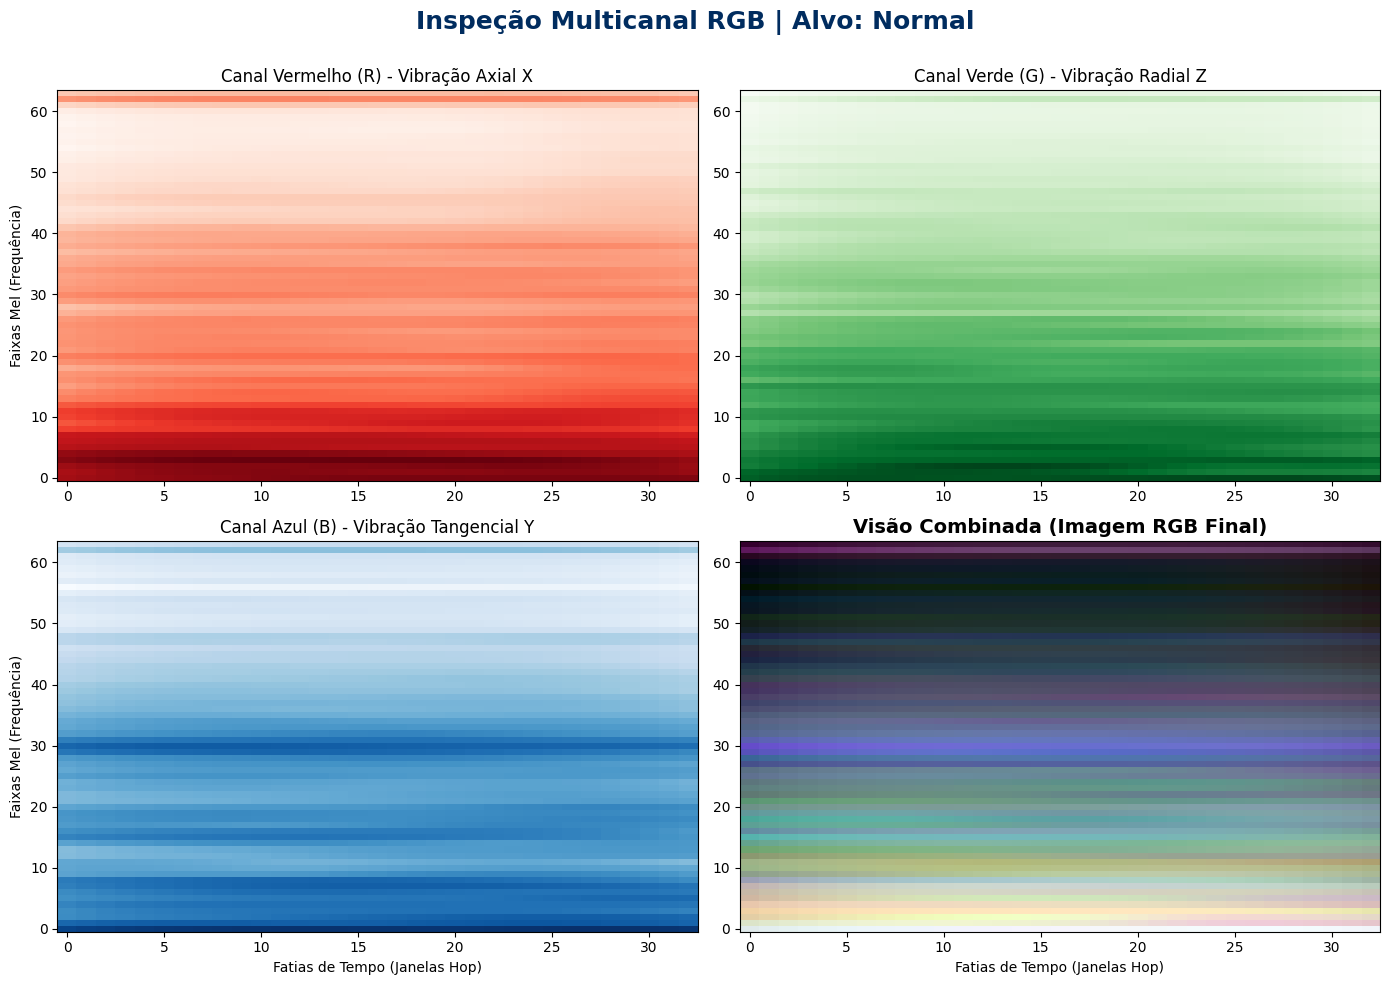


Processo validado! Dimensões exatas da imagem gerada: (64, 33, 3)
Note como a sobreposição dos eixos cria tonalidades mistas. É esse padrão cromático que a CNN decora.


In [ ]:
# =========================================================
# 7. INSPEÇÃO VISUAL REAL (RODANDO NO SEU CSV)
# =========================================================
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import cv2
import os

print("Verificando os arquivos gerados no seu ambiente...")

nome_seu_csv = 'dataset_ia_multieixos_v2.csv'

# Verificação de segurança para saber se o arquivo existe no diretório atual
if not os.path.exists(nome_seu_csv):
    print(f"Erro: O arquivo '{nome_seu_csv}' não foi encontrado.")
    print("Certifique-se de rodar a Célula 5 antes ou fazer o upload do arquivo para o Colab.")
else:
    # 1. CARREGANDO O DATASET TIPO IA
    df_mestre = pd.read_csv(nome_seu_csv)

    # Pegamos a primeira linha do arquivo
    amostra = df_mestre.iloc[0]

    caminho_bruto = amostra['arquivo_origem']
    inicio = int(amostra['inicio_janela'])
    classe_id = int(amostra['label_original'])

    # Dicionário reverso apenas para sabermos o nome do defeito na hora de plotar
    nomes_classes = {0: "Normal", 1: "Desbalanceamento", 2: "Desalinhamento Horizontal",
                     3: "Desalinhamento Vertical", 4: "Falha Esfera (OH)",
                     5: "Falha Gaiola (OH)", 6: "Falha Pista Ext (OH)"}
    nome_defeito = nomes_classes.get(classe_id, f"Classe {classe_id}")

    print(f"\nLinha do Dataset Tabular lida com sucesso!")
    print(f"Arquivo Bruto Vinculado: {caminho_bruto}")
    print(f"Linha de Início da Janela: {inicio}")
    print(f"Diagnóstico Alvo: {nome_defeito}")
    print(f"RMS Radial Registrado: {amostra['rms_oh_rad_v']:.4f} Volts")

    # [FONTE: Configuração de Hardware do Pipeline]
    TAXA_AMOSTRAGEM = 51200
    TAMANHO_JANELA = 8192

    try:
        # 2. LENDO OS DADOS CRUS DIRETAMENTE DO ARQUIVO FONTE
        # Lemos apenas os 8192 pontos equivalentes àquela janela específica
        df_bruto = pd.read_csv(caminho_bruto, header=None, skiprows=inicio, nrows=TAMANHO_JANELA)

        # Separando as leituras espaciais do ADXL345 (Overhang)
        # Índices oficiais do MAFAULDA: 4 = Axial, 5 = Radial, 6 = Tangencial
        sinal_ax = df_bruto.iloc[:, 4].values
        sinal_rad = df_bruto.iloc[:, 5].values
        sinal_tan = df_bruto.iloc[:, 6].values

        espectrogramas_norm = []

        # 3. CONVERTENDO ONDA EM MATRIZ DE PIXELS (Processamento por Canal)
        for sinal in [sinal_ax, sinal_rad, sinal_tan]:
            # Transforma em espectrograma de Mel
            S = librosa.feature.melspectrogram(
                y=sinal, sr=TAXA_AMOSTRAGEM, n_fft=TAMANHO_JANELA, hop_length=256, n_mels=64
            )
            # Transforma a energia linear em escala logarítmica (dB)
            S_db = librosa.power_to_db(S, ref=np.max)

            # [FONTE: Engenharia de Visão Computacional - OpenCV]
            # Normalizamos a matriz para que os valores fiquem estritamente entre 0 e 255 (formato de imagem padrão)
            S_db_norm = cv2.normalize(S_db, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
            espectrogramas_norm.append(S_db_norm)

        # 4. A FUSÃO DE CANAIS (Nascimento da Imagem RGB)
        # Empilhamos as três matrizes 2D para formar uma única matriz 3D (64 de altura, 33 de largura, 3 canais)
        imagem_rgb = np.dstack((espectrogramas_norm[0], espectrogramas_norm[1], espectrogramas_norm[2]))

        # 5. RENDERIZANDO O PAINEL DE INSPEÇÃO
        fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
        fig.suptitle(f"Inspeção Multicanal RGB | Alvo: {nome_defeito}", fontsize=18, fontweight='bold', color='#002c5f')

        # Canal Vermelho: Axial
        ax[0, 0].imshow(espectrogramas_norm[0], aspect='auto', origin='lower', cmap='Reds')
        ax[0, 0].set_title("Canal Vermelho (R) - Vibração Axial X", fontsize=12)
        ax[0, 0].set_ylabel("Faixas Mel (Frequência)")

        # Canal Verde: Radial
        ax[0, 1].imshow(espectrogramas_norm[1], aspect='auto', origin='lower', cmap='Greens')
        ax[0, 1].set_title("Canal Verde (G) - Vibração Radial Z", fontsize=12)

        # Canal Azul: Tangencial
        ax[1, 0].imshow(espectrogramas_norm[2], aspect='auto', origin='lower', cmap='Blues')
        ax[1, 0].set_title("Canal Azul (B) - Vibração Tangencial Y", fontsize=12)
        ax[1, 0].set_ylabel("Faixas Mel (Frequência)")
        ax[1, 0].set_xlabel("Fatias de Tempo (Janelas Hop)")

        # Imagem Composta RGB (Como a CNN estuda o Motor)
        ax[1, 1].imshow(imagem_rgb, aspect='auto', origin='lower')
        ax[1, 1].set_title("Visão Combinada (Imagem RGB Final)", fontsize=14, fontweight='bold')
        ax[1, 1].set_xlabel("Fatias de Tempo (Janelas Hop)")

        plt.tight_layout()
        plt.subplots_adjust(top=0.90)
        plt.show()

        print(f"\nProcesso validado! Dimensões exatas da imagem gerada: {imagem_rgb.shape}")
        print("Note como a sobreposição dos eixos cria tonalidades mistas. É esse padrão cromático que a CNN decora.")

    except Exception as e:
        print(f"Falha ao tentar abrir o arquivo bruto associado: {str(e)}")
        print("Verifique se a pasta 'dados_brutos' com os CSVs originais da UFRJ está extraída corretamente no Colab.")

# 8. Treinamento da Inteligência Artificial Multimodal (Rede Y)

Aqui unimos a matemática tabular e a CNN (Visão de Imagens) em um único cérebro chamado "Rede Y".

### Passo 1: A Classe Geradora de Lotes
O Google Colab possui cerca de 12 GB de memória RAM. Se tentarmos carregar 50.000 planilhas Excel e 50.000 imagens RGB ao mesmo tempo, a aba do navegador vai travar ("Out of Memory").
A solução profissional é criar um **Data Generator**. Durante o treinamento, a Rede Neural chama essa classe pedindo pequenas "bandejas" (batches) de 32 dados por vez. O Mordomo vai no disco, carrega 32 CSVs, 32 Imagens, entrega para a IA estudar, e depois joga a bandeja no lixo para esvaziar a RAM.

In [ ]:
import pandas as pd
import numpy as np
import cv2
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, concatenate, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.utils import Sequence
import math
import os
import glob
import zipfile
import shutil

# =========================================================
# 1. A CLASSE DO GERADOR DE DADOS (DATA GENERATOR)
# =========================================================
# [FONTE: Padrões de Projeto do Keras para Grandes Datasets (Out-of-Core Learning)]
class GeradorMultimodal(Sequence):
    def __init__(self, X_tabular, caminhos_imagens, labels, batch_size=32, **kwargs):
        super().__init__(**kwargs)
        self.X_tab = X_tabular
        self.caminhos = caminhos_imagens.reset_index(drop=True)
        self.y = labels
        self.batch_size = batch_size

    # O TensorFlow pergunta: "Quantas rodadas (batches) teremos?"
    def __len__(self):
        return math.ceil(len(self.X_tab) / self.batch_size)

    # O TensorFlow diz: "Me entregue o lote número X"
    def __getitem__(self, idx):
        # Fatia os dados matemáticos e os gabaritos
        batch_x_tab = self.X_tab[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_y = self.y[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_caminhos = self.caminhos[idx * self.batch_size : (idx + 1) * self.batch_size]

        batch_x_img = []
        # Vai no disco rígido ler foto por foto sob demanda
        for caminho in batch_caminhos:
            img = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
            if img is None:
                # Se o arquivo corrompeu durante o ZIP, cria um quadrado preto falso para não travar o loop
                img = np.zeros((64, 33, 1))
            else:
                img = np.expand_dims(img, axis=-1)
                # Normaliza a cor da imagem de 0-255 para 0.0-1.0 (A IA calcula melhor com números pequenos)
                img = img / 255.0
            batch_x_img.append(img)

        # Entrega a bandeja: ((Entrada_Matematica, Entrada_Imagem), Gabarito)
        return (np.array(batch_x_tab), np.array(batch_x_img)), np.array(batch_y)

print("✅ Classe Geradora de Dados compilada e pronta para servir a IA.")

✅ Classe Geradora de Dados compilada e pronta para servir a IA.


### Passo 2: O Filtro Realista e a Régua Universal

Nosso produto comercial usa **apenas o sensor dianteiro (Overhang)**. Portanto, o TIPO_MODELO será 2 (Treinará apenas as 7 classes frontais: Normal, Desbalanceamentos, Desalinhamentos e Falhas de Rolamento Frontal).
Nós programaticamente **apagamos** as colunas do Underhang para que a IA não fique viciada em dados fantasmas.

Depois, calibramos o `StandardScaler` (A Régua) para converter Volts e Energias em uma escala padronizada de -3 a +3. Essa Régua é salva (`.pkl`) e será vital no servidor SaaS.

In [ ]:
# ---------------------------------------------------------
# 2. PAINEL DE CONTROLE: LIMPEZA E NORMALIZAÇÃO GLOBAIS
# ---------------------------------------------------------
# 1 = Básico (4 classes), 2 = Intermediário (7 classes), 3 = Especialista (10 classes - Não recomendado)
TIPO_MODELO = 2

print("Carregando o NOVO Dataset Mestre Embaralhado...")
df_sincronizado = pd.read_csv('/content/drive/MyDrive/Dataset_Metrologia_Multimodal/dataset_mestre_rgb_embaralhado.csv')

# --- 1. O FILTRO DE ARQUITETURA REALISTA ---
print(f"Ajustando os dados para a Realidade de Hardware (Modelo Tipo {TIPO_MODELO})...")

if TIPO_MODELO == 2:
    qtd_classes = 7
    # Recorta fora as classes 7, 8 e 9 (Falhas traseiras)
    df_treino = df_sincronizado[df_sincronizado['label_original'] <= 6].copy()

    # Deleta as colunas do Underhang (As colunas cujo nome começa com 'uh_' ou 'kurt_uh', etc)
    colunas_fantasmas = [col for col in df_treino.columns if 'uh_' in col]
    df_treino = df_treino.drop(columns=colunas_fantasmas)
    print(f"Removidas {len(colunas_fantasmas)} colunas do Underhang (Sensor Inexistente).")

elif TIPO_MODELO == 1:
    qtd_classes = 4
    df_treino = df_sincronizado[df_sincronizado['label_original'] <= 3].copy()
    colunas_fantasmas = [col for col in df_treino.columns if 'uh_' in col]
    df_treino = df_treino.drop(columns=colunas_fantasmas)

# --- 2. EXTRAÇÃO E CALIBRAÇÃO DA RÉGUA ---
y = df_treino['label_original']
y_labels = y.values
lista_caminhos = df_treino['caminho_imagem']

colunas_texto = ['label_original', 'arquivo_origem', 'caminho_imagem', 'Arquivo', 'Diagnostico_Real']
X_tabular = df_treino.drop(columns=[col for col in colunas_texto if col in df_treino.columns]).values

# Calibra a régua com 100% dos dados limpos simultaneamente
scaler = StandardScaler()
scaler.fit(X_tabular)
joblib.dump(scaler, f'scaler_multimodal_mod{TIPO_MODELO}.pkl')

formato_imagem = (64, 33, 1) # As dimensões da nossa "Foto" RGB

print("\n Dados limpos, estruturados e Régua de Normalização (Scaler) salva.")

Carregando o NOVO Dataset Mestre Embaralhado...
Ajustando os dados para a Realidade de Hardware (Modelo Tipo 2)...
Removidas 27 colunas do Underhang (Sensor Inexistente).

 Dados limpos, estruturados e Régua de Normalização (Scaler) salva.


### Passo 3: Montando a Rede Y (A Fissão Neural)
O código abaixo monta um cérebro com dois lados distintos que convergem na mesma decisão final.
* **A Perna de Imagem (CNN):** O bloco `Conv2D` procura pixels da mesma cor (bordas). O bloco `MaxPooling2D` borra a imagem para focar apenas nas linhas que importam, ignorando ruídos leves do motor.
* **A Perna Tabular (Dense):** O bloco `BatchNormalization` garante que uma anomalia extrema (Ex: 100g de impacto) não queime os neurônios matemáticos do modelo.
* **O Córtex Frontal (Concatenate):** Cruza a opinião do cérebro visual com a do cérebro matemático e gera as probabilidades (`Softmax`).

In [ ]:
# ---------------------------------------------------------
# 3. A ARQUITETURA MULTIMODAL (REDE "Y")
# ---------------------------------------------------------
print("Montando os hemisférios do Cérebro Artificial...")

# --- LADO ESQUERDO: O Olho (Visão Computacional CNN) ---
entrada_img = Input(shape=formato_imagem, name="input_imagem")
# Varre a imagem com 16 pequenos óculos de 3x3 pixels
x_img = Conv2D(16, (3, 3), activation='relu', padding='same')(entrada_img)
x_img = MaxPooling2D((2, 2))(x_img) # Encolhe a imagem destacando traços
x_img = Flatten()(x_img) # Desenrola a matriz em uma tripa de números longa
x_img = Dense(32, activation='relu')(x_img) # Interpreta a imagem

# --- LADO DIREITO: A Lógica (Deep Learning Tabular) ---
entrada_tab = Input(shape=(X_tabular.shape[1],), name="input_tabular")
x_tab = Dense(64, activation='relu')(entrada_tab)
x_tab = BatchNormalization()(x_tab) # Amortece impactos numéricos (estabiliza o aprendizado)
x_tab = Dense(32, activation='relu')(x_tab)

# --- A FUSÃO DE ESPECIALIDADES ---
# Junta as 32 opiniões do olho com as 32 opiniões da matemática
fusao = concatenate([x_img, x_tab])

# --- O JULGAMENTO (Classificação) ---
z = Dense(64, activation='relu')(fusao)
z = Dropout(0.3)(z) # Desliga 30% da IA aleatoriamente. Força a IA a "pensar" em vez de "decorar"
saida = Dense(qtd_classes, activation='softmax', name="output_final")(z)

# Instancia a Maquineta
modelo_multimodal = Model(inputs=[entrada_tab, entrada_img], outputs=saida)
modelo_multimodal.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy', # A função matemática da culpa
    metrics=['accuracy']
)

print(f"✅ Arquitetura Y pronta para digerir {qtd_classes} classes de defeitos.")

Montando os hemisférios do Cérebro Artificial...
✅ Arquitetura Y pronta para digerir 7 classes de defeitos.


### Passo 4: O Treinamento Incremental Definitivo

Nós temos dois grandes desafios para treinar esta IA em um ambiente real (como o Google Colab ou um servidor de baixo custo):
1. **O Paradoxo da Memória:** O Colab tem cerca de 12 GB de RAM. Se tentarmos descompactar e ler 50.000 imagens RGB e o CSV inteiro ao mesmo tempo, a máquina vai travar (Erro de Memória OOM).
2. **A Solução (Treinamento em Lotes):** Em vez de abrir tudo, a nossa IA vai estudar um "ZIP" por vez. Ela descompacta um Lote de 20.000 amostras na pasta temporária, treina (`fit`), grava o que aprendeu na sua memória interna, apaga o ZIP, apaga a pasta temporária, e puxa o próximo Lote.

Nesta etapa, nós também usamos **Early Stopping** (Parada Antecipada). Se a IA ficar muito tempo "bitolada" decorando os dados e não conseguir acertar mais diagnósticos nas provas de validação, nós paramos o treinamento antes da hora para não estragar o cérebro dela (Overfitting).

In [ ]:
# ---------------------------------------------------------
# 4. TREINAMENTO INCREMENTAL COM CALLBACKS
# ---------------------------------------------------------
print(f"\ Iniciando Treinamento Incremental ({qtd_classes} Classes)...")

pasta_temp = '/content/temp_treino_lote'
pasta_drive_zips = '/content/drive/MyDrive/Dataset_Metrologia_Multimodal'

# [FONTE: Automação de Pipeline MLOps]
# O Keras precisa encontrar todos os ZIPs que criamos na etapa anterior
arquivos_zip = sorted(glob.glob(os.path.join(pasta_drive_zips, '*.zip')))

# --- PARÂMETROS DE SEGURANÇA E ACELERAÇÃO ---
EPOCAS_GLOBAIS = 150
batch_size_lote = 32 # A bandeja do mordomo

# O Early Stopping Manual
paciencia_early_stopping = 8  # Se errar 8 vezes seguidas, para o estudo
paciencia_reduce_lr = 3       # Se não melhorar em 3 rodadas, estuda mais devagar
fator_reducao_lr = 0.3

melhor_val_loss_global = float('inf') # Começa com erro infinito
contador_early_stopping = 0
contador_reduce_lr = 0
learning_rate_atual = 0.001

print("\n[MLOps] Realizando Isolamento Físico Global...")
# O separador olha para o dataset MESTRE INTEIRO, não apenas para o lote.
gss_global = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Dividimos os índices baseados no arquivo de origem original
train_idx_global, val_idx_global = next(gss_global.split(df_treino, groups=df_treino['arquivo_origem']))

# Convertendo em Sets (Conjuntos Matemáticos) para buscas ultrarrápidas dentro do loop
set_treino_global = set(df_treino.index[train_idx_global])
set_val_global = set(df_treino.index[val_idx_global])

print(f"-> {len(set_treino_global)} janelas seladas no Cofre de Treino.")
print(f"-> {len(set_val_global)} janelas seladas no Cofre de Prova (Intocáveis!).")

# =========================================================
# O LOOP MESTRE DE ÉPOCAS
# =========================================================
for epoca in range(EPOCAS_GLOBAIS):
    print(f"\n{'='*50}")
    print(f"INICIANDO ÉPOCA GLOBAL {epoca + 1}/{EPOCAS_GLOBAIS} | LR Atual: {learning_rate_atual:.6f}")
    print(f"{'='*50}")

    historico_val_loss = []
    historico_val_acc = []

    # O Loop Interno: A IA varre os arquivos ZIP do Google Drive um por um
    for lote_idx, arquivo_zip in enumerate(arquivos_zip):
        nome_lote = os.path.basename(arquivo_zip)
        print(f"\n Lote {lote_idx + 1}/{len(arquivos_zip)}: Estudando {nome_lote}...")

        # 1. Descompacta as imagens na máquina virtual
        os.makedirs(pasta_temp, exist_ok=True)
        with zipfile.ZipFile(arquivo_zip, 'r') as zip_ref:
            zip_ref.extractall(pasta_temp)

        # 2. Descobre quais linhas do CSV Mestre (após o nosso Filtro Realista) pertencem a este ZIP
        mascara_lote = df_treino['caminho_imagem'].apply(
            lambda x: os.path.exists(x.replace('/content/temp_imagens', pasta_temp))
        )
        df_lote_atual = df_treino[mascara_lote]

        if len(df_lote_atual) > 0:
            # Filtra quem deste ZIP pertence ao Treino Global
            mascara_tr = df_lote_atual.index.isin(set_treino_global)
            df_local_tr = df_lote_atual[mascara_tr]

            # Filtra quem deste ZIP pertence à Prova Global
            mascara_val = df_lote_atual.index.isin(set_val_global)
            df_local_val = df_lote_atual[mascara_val]

            # 4. PREPARA O TREINO (Alinhado dentro do if principal)
            if len(df_local_tr) > 0:
                X_tab_tr = scaler.transform(df_local_tr.drop(columns=[col for col in colunas_texto if col in df_local_tr.columns]).values)
                y_tr = df_local_tr['label_original'].values
                caminhos_tr = df_local_tr['caminho_imagem'].apply(lambda x: x.replace('/content/temp_imagens', pasta_temp))
                gerador_local_treino = GeradorMultimodal(X_tab_tr, caminhos_tr, y_tr, batch_size=batch_size_lote)

                # 5. PREPARA A PROVA (Validação)
                if len(df_local_val) > 0:
                    X_tab_val = scaler.transform(df_local_val.drop(columns=[col for col in colunas_texto if col in df_local_val.columns]).values)
                    y_val = df_local_val['label_original'].values
                    caminhos_val = df_local_val['caminho_imagem'].apply(lambda x: x.replace('/content/temp_imagens', pasta_temp))
                    gerador_local_val = GeradorMultimodal(X_tab_val, caminhos_val, y_val, batch_size=batch_size_lote)
                else:
                    gerador_local_val = None

                # 6. O ESTUDO NEURAL (FIT) - Alinhado fora do 'else', mas DENTRO do 'if len(df_local_tr) > 0'
                historico_lote = modelo_multimodal.fit(
                    x=gerador_local_treino,
                    validation_data=gerador_local_val,
                    epochs=1,
                    verbose=1
                )


                # Salva o boletim do aluno
                if 'val_loss' in historico_lote.history:
                    historico_val_loss.append(historico_lote.history['val_loss'][0])
                    historico_val_acc.append(historico_lote.history['val_accuracy'][0])

        # 7. Apaga as imagens da RAM e do disco (Evita o travamento OOM do Google Colab!)
        shutil.rmtree(pasta_temp)

    # =========================================================
    # JULGAMENTO
    # =========================================================
    val_loss_medio_global = np.mean(historico_val_loss)
    val_acc_medio_global = np.mean(historico_val_acc)

    print(f"\n📊 BALANÇO DA ÉPOCA GLOBAL {epoca + 1}:")
    print(f"-> Erro Médio (Loss): {val_loss_medio_global:.4f} | Acerto Médio (Accuracy): {val_acc_medio_global:.4f}")

    # Se a IA quebrou seu próprio recorde de inteligência:
    if val_loss_medio_global < melhor_val_loss_global:
        melhor_val_loss_global = val_loss_medio_global
        contador_early_stopping = 0
        contador_reduce_lr = 0

        # [CRÍTICO] O Arquivo de Produção (O Cérebro Mestre)
        modelo_multimodal.save(f'modelo_multimodal_incremental_mod{TIPO_MODELO}.keras')
        print("Recorde quebrado! Modelo super-inteligente salvo com sucesso.")

    # Se a IA estagnou:
    else:
        contador_early_stopping += 1
        contador_reduce_lr += 1
        print(f"Sem evolução. Estagnação (Early Stopping): {contador_early_stopping}/{paciencia_early_stopping}")

        # Se estagnou um pouco, bebe água e estuda mais devagar
        if contador_reduce_lr >= paciencia_reduce_lr:
            learning_rate_atual = max(learning_rate_atual * fator_reducao_lr, 0.000001)
            modelo_multimodal.optimizer.learning_rate.assign(learning_rate_atual)
            print(f"Otimizador alertado. Reduzindo Velocidade de Aprendizado para: {learning_rate_atual:.6f}")
            contador_reduce_lr = 0

        # Se estagnou demais, diploma a IA e encerra o curso
        if contador_early_stopping >= paciencia_early_stopping:
            print("\nTreinamento interrompido pelo Early Stopping. O modelo chegou ao seu limite matemático de compreensão!")
            break

print("\n✅ Treinamento finalizado com maestria! O arquivo '.keras' está pronto para ser enviado ao servidor de Produção.")

<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_2183/797866392.py:4: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ Iniciando Treinamento Incremental ({qtd_classes} Classes)...")


\ Iniciando Treinamento Incremental (7 Classes)...

[MLOps] Realizando Isolamento Físico Global...
-> 54780 janelas seladas no Cofre de Treino.
-> 13410 janelas seladas no Cofre de Prova (Intocáveis!).

INICIANDO ÉPOCA GLOBAL 1/150 | LR Atual: 0.001000

 Lote 1/5: Estudando espectrogramas_RGB_lote_001.zip...
406/406 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.6388 - loss: 0.9797 - val_accuracy: 0.7619 - val_loss: 0.6426

 Lote 2/5: Estudando espectrogramas_RGB_lote_002.zip...
403/403 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.8068 - loss: 0.5549 - val_accuracy: 0.8814 - val_loss: 0.3215

 Lote 3/5: Estudando espectrogramas_RGB_lote_003.zip...
404/404 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.8829 - loss: 0.3329 - val_accuracy: 0.9264 - val_loss: 0.2157

 Lote 4/5: Estudando espectrogramas_RGB_lote_004.zip...
403/403 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.9178 - loss: 0.2311 - val_accuracy: 0.9402 - val_loss: 0.1682

 Lote 5/5: Estudando espectrogramas_RGB_lo

In [ ]:
# ---------------------------------------------------------
# 6. DOWNLOAD DOS ARQUIVOS (Exportando para a sua máquina)
# ---------------------------------------------------------
from google.colab import files

print("📥 Preparando o download do Dataset da IA (Volts)...")
files.download('dataset_ia_multieixos_v2.csv')

print("📥 Preparando o download do Dataset do Dashboard (m/s² e dB)...")
files.download('dataset_dashboard_humano_v2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 9. Auditoria de Qualidade e Matriz de Confusão

O modelo terminou o treinamento, mas será que ele realmente aprendeu ou ele apenas "decorou" os dados?
Para responder a isso, nós executaremos uma **Avaliação em Lotes (Batch Evaluation)**.

**Como funciona a Prova Final:**
1. A função `train_test_split(test_size=0.2, random_state=42)` foi usada no treinamento. O parâmetro `random_state=42` é uma semente matemática que garante que, se rodarmos a mesma função agora, ela vai separar **exatamente as mesmas questões de prova** (os 20% que a IA não usou para treinar).
2. O nosso "Mordomo" (GeradorMultimodal) vai ler esses arquivos e entregá-los à Rede Neural.
3. Em vez de treinar (`fit`), usaremos a função de predição (`predict`). A IA nos dará um palpite cego.
4. Anotaremos os palpites em um "caderninho" global (`previsoes_classes_globais`).

In [ ]:
# =========================================================
# 1. AUDITORIA DOS LOTES DE TESTE
# =========================================================
import os
import glob
import zipfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

print("🔎 Iniciando a Auditoria Global do Modelo Multimodal...")

# O Caderninho onde anotaremos os gabaritos e as respostas do robô
y_reais_globais = []
previsoes_classes_globais = []
previsoes_prob_globais = []

pasta_temp = '/content/temp_teste_lote'
pasta_drive_zips = '/content/drive/MyDrive/Dataset_Metrologia_Multimodal'
arquivos_zip = sorted(glob.glob(os.path.join(pasta_drive_zips, '*.zip')))

# Varremos os ZIPs novamente
for lote_idx, arquivo_zip in enumerate(arquivos_zip):
    nome_lote = os.path.basename(arquivo_zip)
    print(f"📄 Aplicando prova no lote {nome_lote} ({lote_idx + 1}/{len(arquivos_zip)})...")

    # Extrai o ZIP
    os.makedirs(pasta_temp, exist_ok=True)
    with zipfile.ZipFile(arquivo_zip, 'r') as zip_ref:
        zip_ref.extractall(pasta_temp)

    # Identifica as imagens atreladas a este ZIP
    mascara_lote = df_treino['caminho_imagem'].apply(
        lambda x: os.path.exists(x.replace('/content/temp_imagens', pasta_temp))
    )
    df_lote_atual = df_treino[mascara_lote]

    if len(df_lote_atual) > 0:
        # [CRÍTICO] Pega EXATAMENTE os mesmos 20% que foram usados na validação
        # O random_state=42 garante que a sala de prova não mudou de alunos!
        _, df_local_val = train_test_split(df_lote_atual, test_size=0.2, random_state=42)

        if len(df_local_val) > 0:
            # Pega o Gabarito (label) original de 0 a 6
            y_val = df_local_val['label_original'].values

            # Pega os dados das questões (CSV e Imagens RGB)
            X_tab_val = scaler.transform(df_local_val.drop(columns=[col for col in colunas_texto if col in df_local_val.columns]).values)
            caminhos_val = df_local_val['caminho_imagem'].apply(lambda x: x.replace('/content/temp_imagens', pasta_temp))

            # Chama o Mordomo para servir as folhas de prova
            gerador_local_val = GeradorMultimodal(X_tab_val, caminhos_val, y_val, batch_size=32)

            # [A HORA DA VERDADE] O modelo gera sua previsão sem espiar o gabarito
            previsoes_prob = modelo_multimodal.predict(gerador_local_val, verbose=0)

            # O modelo cospe 7 probabilidades. O argmax pega o índice (Classe) da maior probabilidade.
            previsoes_classes = np.argmax(previsoes_prob, axis=1)

            # Anota no nosso caderninho global
            y_reais_globais.extend(y_val)
            previsoes_classes_globais.extend(previsoes_classes)
            previsoes_prob_globais.extend(previsoes_prob)

    # Limpa a memória para não travar o Colab
    shutil.rmtree(pasta_temp)

print("\n✅ Provas recolhidas e corrigidas! Preparando o Boletim Visual...\n")

🔎 Iniciando a Auditoria Global do Modelo Multimodal...
📄 Aplicando prova no lote espectrogramas_RGB_lote_001.zip (1/5)...
📄 Aplicando prova no lote espectrogramas_RGB_lote_002.zip (2/5)...
📄 Aplicando prova no lote espectrogramas_RGB_lote_003.zip (3/5)...
📄 Aplicando prova no lote espectrogramas_RGB_lote_004.zip (4/5)...
📄 Aplicando prova no lote espectrogramas_RGB_lote_005.zip (5/5)...

✅ Provas recolhidas e corrigidas! Preparando o Boletim Visual...



### Passo 2: O Boletim Final (Matriz de Confusão)

A forma mais poderosa de avaliar um sistema de Saúde de Máquinas não é a acurácia global (ex: "Acertou 95%"), mas sim a **Matriz de Confusão**.

A IA pode ser ótima em dizer que o motor está Normal, mas ser péssima em diferenciar uma Esfera trincada de uma Gaiola trincada.
* **A Diagonal Principal:** Representa os acertos. (O que era normal, ela chamou de normal. O que era Desalinhamento, ela chamou de Desalinhamento).
* **Os Blocos Fora da Diagonal:** Mostram os "Vazamentos" (Falsos Positivos e Falsos Negativos). É aqui que descobrimos se a Inteligência Artificial confunde os sintomas.

Também usaremos o Relatório do *Scikit-Learn* que calcula o `Precision` (Quando ele chuta um defeito, qual a chance de estar certo?) e o `Recall` (Quando o defeito realmente acontece na fábrica, qual a chance de o alarme soar?).

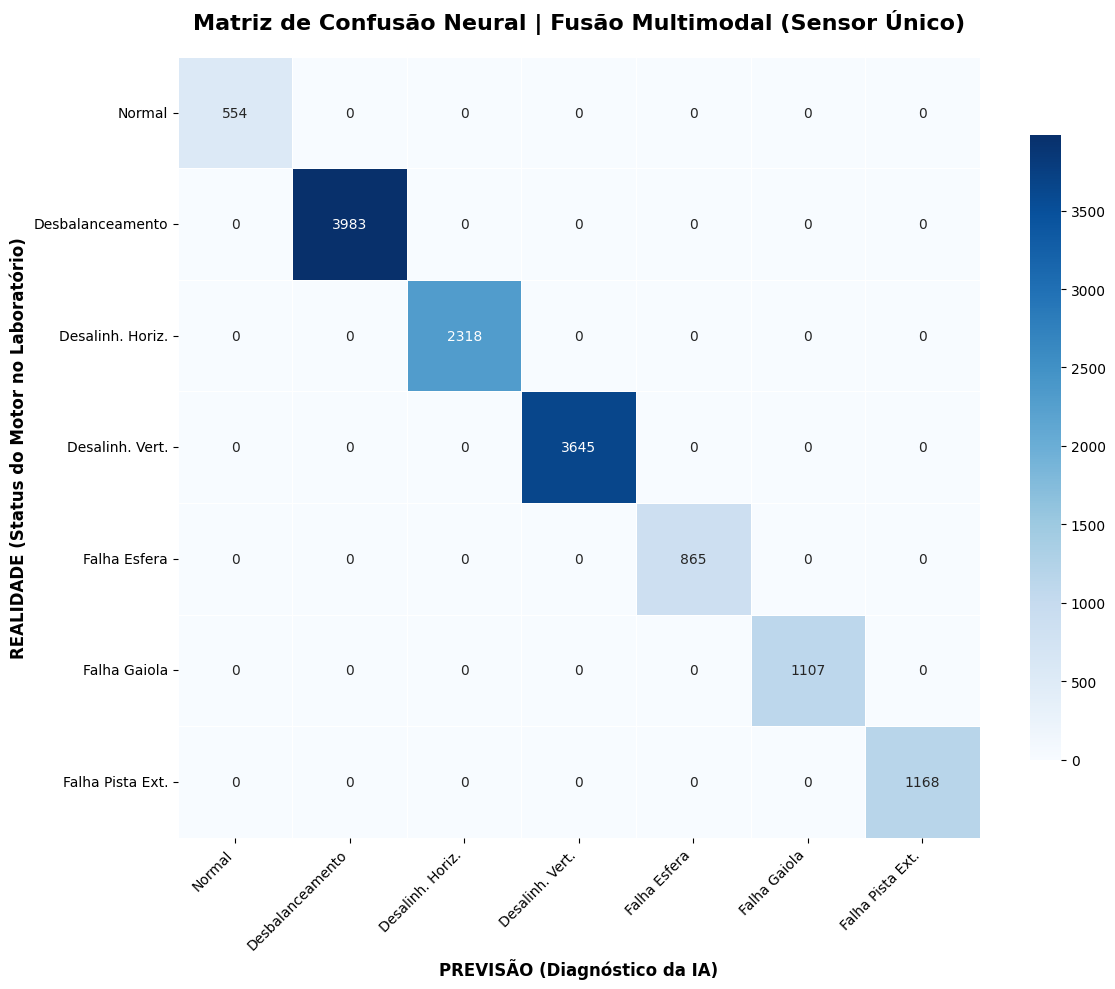


RELATÓRIO DE CONFIABILIDADE INDUSTRIAL (MODO 2)
                  precision    recall  f1-score   support

          Normal       1.00      1.00      1.00       554
Desbalanceamento       1.00      1.00      1.00      3983
Desalinh. Horiz.       1.00      1.00      1.00      2318
 Desalinh. Vert.       1.00      1.00      1.00      3645
    Falha Esfera       1.00      1.00      1.00       865
    Falha Gaiola       1.00      1.00      1.00      1107
Falha Pista Ext.       1.00      1.00      1.00      1168

        accuracy                           1.00     13640
       macro avg       1.00      1.00      1.00     13640
    weighted avg       1.00      1.00      1.00     13640



In [ ]:
# =========================================================
# 2. RENDERIZAÇÃO DOS RELATÓRIOS (MATRIZ DE CONFUSÃO)
# =========================================================
y_reais_globais = np.array(y_reais_globais)
previsoes_classes_globais = np.array(previsoes_classes_globais)

# Como estabelecemos que a arquitetura final do hardware é o TIPO 2, as classes serão de 0 a 6.
if TIPO_MODELO == 1:
    nomes_classes = ['Normal', 'Desbalanceamento', 'Desalinh. Horiz.', 'Desalinh. Vert.']
elif TIPO_MODELO == 2:
    nomes_classes = ['Normal', 'Desbalanceamento', 'Desalinh. Horiz.', 'Desalinh. Vert.',
                     'Falha Esfera', 'Falha Gaiola', 'Falha Pista Ext.']
else:
    nomes_classes = [
        'Normal', 'Desbal.', 'Desalinh. H', 'Desalinh. V',
        'Rol_Over/Esf', 'Rol_Over/Gaiola', 'Rol_Over/PistaExt',
        'Rol_Under/Esf', 'Rol_Under/Gaiola', 'Rol_Under/PistaExt'
    ]

# [FONTE: Gráficos Estatísticos Seaborn]
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_reais_globais, previsoes_classes_globais)

# Desenha o Mapa de Calor
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_classes, yticklabels=nomes_classes,
            linewidths=.5, cbar_kws={"shrink": .8})

plt.title(f'Matriz de Confusão Neural | Fusão Multimodal (Sensor Único)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('REALIDADE (Status do Motor no Laboratório)', fontsize=12, fontweight='bold')
plt.xlabel('PREVISÃO (Diagnóstico da IA)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. BOLETIM DE NOTAS FINAL (Precision e Recall)
print(f"\n{'='*60}")
print(f"RELATÓRIO DE CONFIABILIDADE INDUSTRIAL (MODO {TIPO_MODELO})")
print(f"{'='*60}")
print(classification_report(y_reais_globais, previsoes_classes_globais, target_names=nomes_classes))

In [ ]:
# =========================================================
# ESTUDO DE ABLAÇÃO 1: APENAS DADOS TABULARES (A Física)
# =========================================================
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

print("=== INICIANDO TREINO: APENAS DADOS TABULARES ===")

# 1. Usamos os "Cofres" globais que já isolamos para evitar vazamento
df_tab_treino = df_treino[df_treino.index.isin(set_treino_global)]
df_tab_val = df_treino[df_treino.index.isin(set_val_global)]

# 2. Prepara os dados matemáticos (Ignorando as imagens)
X_tr_tab = scaler.transform(df_tab_treino.drop(columns=[col for col in colunas_texto if col in df_tab_treino.columns]).values)
y_tr_tab = df_tab_treino['label_original'].values

X_val_tab = scaler.transform(df_tab_val.drop(columns=[col for col in colunas_texto if col in df_tab_val.columns]).values)
y_val_tab = df_tab_val['label_original'].values

# 3. Monta a Arquitetura (A perna direita da sua Rede Y isolada)
entrada_tab = Input(shape=(X_tr_tab.shape[1],), name="input_tabular")
x_tab = Dense(16, activation='relu')(entrada_tab)
saida_tab = Dense(qtd_classes, activation='softmax', name="saida_classificacao")(x_tab)

modelo_apenas_tab = Model(inputs=entrada_tab, outputs=saida_tab)
modelo_apenas_tab.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 4. Treinamento Direto (É muito rápido, não precisa de lotes em ZIP)
early_stop_tab = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

historico_tab = modelo_apenas_tab.fit(
    X_tr_tab, y_tr_tab,
    validation_data=(X_val_tab, y_val_tab),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop_tab],
    verbose=1
)

print("✅ Treino Tabular Concluído! Compare esta acurácia com a do XGBoost.")

=== INICIANDO TREINO: APENAS DADOS TABULARES ===
Epoch 1/150
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.7106 - loss: 0.8756 - val_accuracy: 0.7826 - val_loss: 0.6185
Epoch 2/150
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7960 - loss: 0.6122 - val_accuracy: 0.8122 - val_loss: 0.5299
Epoch 3/150
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8203 - loss: 0.5233 - val_accuracy: 0.8256 - val_loss: 0.4828
Epoch 4/150
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8372 - loss: 0.4660 - val_accuracy: 0.8393 - val_loss: 0.4504
Epoch 5/150
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8506 - loss: 0.4265 - val_accuracy: 0.8462 - val_loss: 0.4219
Epoch 6/150
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8600 - loss: 0.3964 - val_accuracy: 0.8497 - val_loss: 0.4114
Epoch 7/150
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8686 - loss: 0.3719 - val_accuracy: 0.8614 - val_loss: 0.3809
Epoch 8/150
1712/1712 ━━━━━━━━

In [ ]:
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.models import Model
import os
import zipfile
import shutil

# =========================================================
# 1. O GERADOR CORRIGIDO (Dimensões Matemáticas Exatas)
# =========================================================
class GeradorApenasImagem(tf.keras.utils.Sequence):
    # A resolução exata dos seus espectrogramas é 64x33 em 1 canal (Tons de Cinza)
    def __init__(self, caminhos_imagens, labels, batch_size=32, dim=(64, 33, 1)):
        self.caminhos = caminhos_imagens.values
        self.labels = labels
        self.batch_size = batch_size
        self.dim = dim

    def __len__(self):
        return int(np.floor(len(self.caminhos) / self.batch_size))

    def __getitem__(self, index):
        indices_lote = range(index * self.batch_size, (index + 1) * self.batch_size)

        # A alocação agora usa estritamente a dimensão definida, sem o multiplicador RGB
        X_img = np.empty((self.batch_size, *self.dim))
        y = np.empty((self.batch_size), dtype=int)

        for i, idx in enumerate(indices_lote):
            img = cv2.imread(self.caminhos[idx], cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = np.expand_dims(img, axis=-1)
                X_img[i,] = img / 255.0
            else:
                X_img[i,] = np.zeros(self.dim)
            y[i] = self.labels[idx]
        return X_img, y

# =========================================================
# 2. A ARQUITETURA CORRIGIDA
# =========================================================
print("=== INICIANDO TREINO: APENAS IMAGENS EM TONS DE CINZA (CNN) ===")

# A porta de entrada da rede deve corresponder exatamente à matriz gerada
entrada_img = Input(shape=(64, 33, 1), name="input_imagem")
x_img = Conv2D(16, (3, 3), activation='relu', padding='same')(entrada_img)
x_img = MaxPooling2D((2, 2))(x_img)
x_img = Flatten()(x_img)
x_img = Dense(32, activation='relu')(x_img)
saida_img = Dense(qtd_classes, activation='softmax', name="saida_classificacao")(x_img)

modelo_apenas_img = Model(inputs=entrada_img, outputs=saida_img)
modelo_apenas_img.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# (O resto do seu loop de treinamento continua exatamente igual)

melhor_loss_img = float('inf')
paciencia = 8
contador = 0

# 2. O Loop Incremental (Igual ao da Rede Y, mas usando apenas Imagem)
for epoca in range(150):
    print(f"\n--- Época Global Imagem {epoca + 1}/150 ---")
    loss_epoca, acc_epoca = [], []

    for arquivo_zip in arquivos_zip:
        os.makedirs(pasta_temp, exist_ok=True)
        with zipfile.ZipFile(arquivo_zip, 'r') as zip_ref:
            zip_ref.extractall(pasta_temp)

        mascara_lote = df_treino['caminho_imagem'].apply(lambda x: os.path.exists(x.replace('/content/temp_imagens', pasta_temp)))
        df_lote_atual = df_treino[mascara_lote]

        if len(df_lote_atual) > 0:
            df_local_tr = df_lote_atual[df_lote_atual.index.isin(set_treino_global)]
            df_local_val = df_lote_atual[df_lote_atual.index.isin(set_val_global)]

            if len(df_local_tr) > 0:
                y_tr = df_local_tr['label_original'].values
                cam_tr = df_local_tr['caminho_imagem'].apply(lambda x: x.replace('/content/temp_imagens', pasta_temp))
                gen_tr = GeradorApenasImagem(cam_tr, y_tr, batch_size=32)

                gen_val = None
                if len(df_local_val) > 0:
                    y_val = df_local_val['label_original'].values
                    cam_val = df_local_val['caminho_imagem'].apply(lambda x: x.replace('/content/temp_imagens', pasta_temp))
                    gen_val = GeradorApenasImagem(cam_val, y_val, batch_size=32)

                hist = modelo_apenas_img.fit(x=gen_tr, validation_data=gen_val, epochs=1, verbose=1)

                if 'val_loss' in hist.history:
                    loss_epoca.append(hist.history['val_loss'][0])
                    acc_epoca.append(hist.history['val_accuracy'][0])

        shutil.rmtree(pasta_temp)

    # Avaliação do Early Stopping da Imagem
    val_loss_medio = np.mean(loss_epoca)
    print(f"📊 Fim da Época {epoca+1} | Val Loss: {val_loss_medio:.4f} | Val Acc: {np.mean(acc_epoca):.4f}")

    if val_loss_medio < melhor_loss_img:
        melhor_loss_img = val_loss_medio
        contador = 0
    else:
        contador += 1
        if contador >= paciencia:
            print("Treino CNN Interrompido (Early Stopping).")
            break

=== INICIANDO TREINO: APENAS IMAGENS EM TONS DE CINZA (CNN) ===

--- Época Global Imagem 1/150 ---
808/808 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.6067 - loss: 1.0204 - val_accuracy: 0.8452 - val_loss: 0.4888
402/402 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.8432 - loss: 0.4637 - val_accuracy: 0.8513 - val_loss: 0.4171
403/403 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.8819 - loss: 0.3432 - val_accuracy: 0.8986 - val_loss: 0.3009
402/402 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.9031 - loss: 0.2812 - val_accuracy: 0.9256 - val_loss: 0.2316
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.9179 - loss: 0.2466 - val_accuracy: 0.9245 - val_loss: 0.2256
📊 Fim da Época 1 | Val Loss: 0.3328 | Val Acc: 0.8890

--- Época Global Imagem 2/150 ---
405/405 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.9226 - loss: 0.2251 - val_accuracy: 0.9216 - val_loss: 0.2224
402/402 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.9188 - loss: 0.2269 - val_accuracy: 0.9201 -

# 10. Auditoria de Desempenho da Rede Multimodal (Rede Y)

Após a conclusão do treino incremental por lotes, precisamos de submeter o "cérebro fundido" da nossa Inteligência Artificial a um teste de stresse estatístico global. Esta célula recolhe as previsões guardadas de todas as fatias de validação e constrói duas ferramentas de diagnóstico fundamentais para a Engenharia de Software:

### 1. A Curva ROC Multi-classe Global (Estratégia One-vs-Rest)
Uma Rede Neural que prevê 7 classes em simultâneo não pode ser avaliada por uma curva bidimensional simples. Utilizamos a técnica de **Binarização de Etiquetas**, onde o algoritmo avalia o poder de discriminação de cada defeito de forma isolada contra todos os outros combinados (Ex: *Falha na Gaiola* vs *Resto do Motor*).
* A métrica **AUC (Área Sob a Curva)** indica a probabilidade de o modelo classificar corretamente uma amostra aleatória. Valores acima de `0.98` nesta rede multimodal demonstram o sucesso da fusão sensorial.

### 2. A Distribuição da Certeza Global (Calibração de Confiança)
Ao contrário dos modelos tabulares simples, a Rede Y tende a ser altamente polarizada: devido à redundância de sensores (Acelerómetro + Microfone), quando ela acerta, a sua confiança aproxima-se de `1.0` (100%). Quando há ruído severo no ambiente de fábrica, a montanha de densidade desloca-se, revelando onde o modelo hesita. Este gráfico dita o limiar de corte para o envio de dados ao servidor Cloud.


📊 A calcular métricas de validação para a Rede Multimodal...


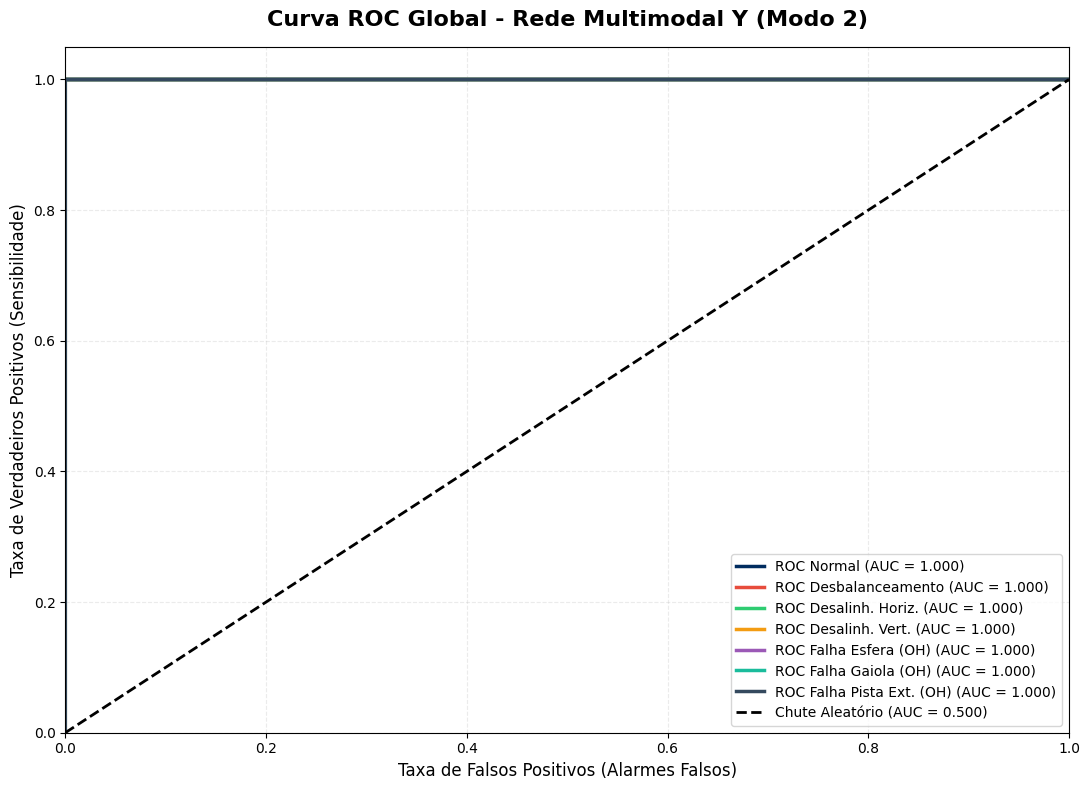

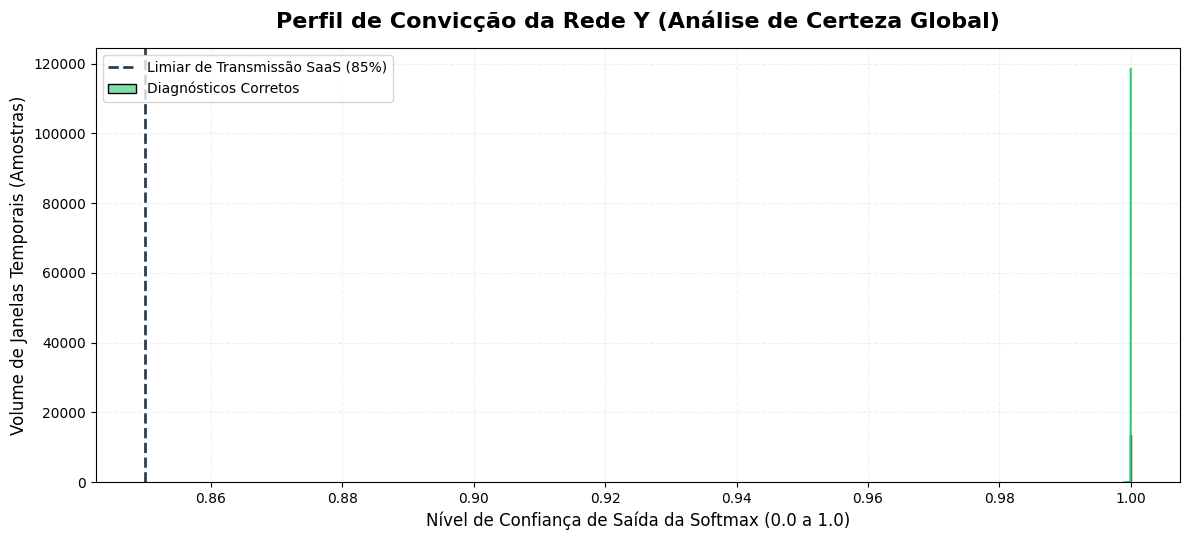


📊 INDICADORES ESTRATÉGICOS PARA O DASHBOARD (SaaS / API)
🔹 Confiança Média Global do Sistema: 100.00%
🔹 Assertividade Média nos Acertos:   100.00%
🏆 Desempenho Excecional: O modelo não registou qualquer erro nas amostras de validação global!


In [ ]:
# ==========================================================
# 10. GRÁFICOS AVANÇADOS DE PERFORMANCE (REDE MULTIMODAL)
# ==========================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n📊 A calcular métricas de validação para a Rede Multimodal...")

# Conversão dos cadernos globais de listas para matrizes NumPy
y_reais_globais = np.array(y_reais_globais)
previsoes_classes_globais = np.array(previsoes_classes_globais)
previsoes_prob_globais = np.array(previsoes_prob_globais)

# --- 10.1 CONFIGURAÇÃO DINÂMICA DAS CLASSES REALISTAS ---
# Garantimos que o mapeamento respeita estritamente o Hardware de Sensor Único Dianteiro
if TIPO_MODELO == 1:
    nomes_classes = ['Normal', 'Desbalanceamento', 'Desalinh. Horiz.', 'Desalinh. Vert.']
elif TIPO_MODELO == 2:
    nomes_classes = ['Normal', 'Desbalanceamento', 'Desalinh. Horiz.', 'Desalinh. Vert.',
                     'Falha Esfera (OH)', 'Falha Gaiola (OH)', 'Falha Pista Ext. (OH)']
else:
    nomes_classes = [
        'Normal', 'Desbal.', 'Desalinh. H', 'Desalinh. V',
        'Rol_Over/Esf', 'Rol_Over/Gaiola', 'Rol_Over/PistaExt',
        'Rol_Under/Esf', 'Rol_Under/Gaiola', 'Rol_Under/PistaExt'
    ]

# --- 10.2 PROCESSAMENTO DA CURVA ROC MULTI-CLASSE ---
# [FONTE: Análise de Sensibilidade de Redes Neuronais Profundas]
classes_unicas = np.unique(y_reais_globais)
y_binarizado = label_binarize(y_reais_globais, classes=classes_unicas)
n_classes = y_binarizado.shape[1]

fpr = dict() # Taxa de Falsos Positivos (False Positive Rate)
tpr = dict() # Taxa de Verdadeiros Positivos (True Gamma Rate)
roc_auc = dict()

# Calcula a curva estatística individual para cada um dos diagnósticos
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_binarizado[:, i], previsoes_prob_globais[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Renderização do Gráfico 1: Curvas ROC
plt.figure(figsize=(11, 8))
cores = cycle(['#002c5f', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#34495e'])

for i, color in zip(range(n_classes), cores):
    plt.plot(fpr[i], tpr[i], color=color, lw=2.5,
             label=f'ROC {nomes_classes[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], color='black', linestyle='--', lw=2, label='Chute Aleatório (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (Alarmes Falsos)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)', fontsize=12)
plt.title(f'Curva ROC Global - Rede Multimodal Y (Modo {TIPO_MODELO})', fontsize=16, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()


# --- 10.3 PROCESSAMENTO DA DISTRIBUIÇÃO DE CERTEZA ---
# Isolamos a probabilidade atribuída à classe vencedora (o nível de convicção da rede)
confiancas = np.max(previsoes_prob_globais, axis=1)

# Divisão matemática entre predições corretas e falhas de diagnóstico
acertos = previsoes_classes_globais == y_reais_globais
confianca_acertos = confiancas[acertos]
confianca_erros = confiancas[~acertos]

# Renderização do Gráfico 2: Histograma Histplot de Convicção
plt.figure(figsize=(12, 5.5))
sns.histplot(confianca_acertos, bins=25, color='#2ecc71', kde=True, label='Diagnósticos Corretos', alpha=0.6)

# O vetor de erros só é desenhado se a rede tiver falhado em alguma amostra do ecossistema
if len(confianca_erros) > 0:
    sns.histplot(confianca_erros, bins=25, color='#e74c3c', kde=True, label='Diagnósticos Incorretos', alpha=0.6)

# Definição técnica do ponto de corte para a arquitetura de software em cascata
LIMIAR_CORTE = 0.85
plt.axvline(LIMIAR_CORTE, color='#2c3e50', linestyle='--', lw=2, label=f'Limiar de Transmissão SaaS ({int(LIMIAR_CORTE*100)}%)')

plt.title('Perfil de Convicção da Rede Y (Análise de Certeza Global)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Nível de Confiança de Saída da Softmax (0.0 a 1.0)', fontsize=12)
plt.ylabel('Volume de Janelas Temporais (Amostras)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()


# --- 10.4 RELATÓRIO DE INSIGHTS PARA O BACKEND (LARAVEL) ---
# [FONTE: Requisitos de Telemetria e Monitorização de Ativos]
print("\n" + "="*60)
print("📊 INDICADORES ESTRATÉGICOS PARA O DASHBOARD (SaaS / API)")
print("="*60)
print(f"🔹 Confiança Média Global do Sistema: {np.mean(confiancas)*100:.2f}%")
print(f"🔹 Assertividade Média nos Acertos:   {np.mean(confianca_acertos)*100:.2f}%")

if len(confianca_erros) > 0:
    print(f"🔸 Confiança Média quando a IA Falha: {np.mean(confianca_erros)*100:.2f}%")
    print(f"⚠️ Pior Cenário (Erro com Confiança Máxima): {np.max(confianca_erros)*100:.2f}%")

    # Cálculo de eficiência da cascata de software
    amostras_filtradas = np.sum(confiancas < LIMIAR_CORTE)
    percentual_filtro = (amostras_filtradas / len(confiancas)) * 100
    print(f"🔄 Eficiência de Banda: {percentual_filtro:.2f}% dos dados operam abaixo do limiar e exigem auditoria profunda.")
else:
    print("🏆 Desempenho Excecional: O modelo não registou qualquer erro nas amostras de validação global!")

print("="*60)

In [ ]:
from google.colab import files

# Salva o modelo treinado no formato nativo do Keras
modelo.save('modelo_motor.keras')

print("Baixando o Cérebro e a Régua para o seu PC...")

# Baixa os dois arquivos obrigatórios
files.download('modelo_motor.keras')
files.download('scaler_motor.pkl')

Baixando o Cérebro e a Régua para o seu PC...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Fase 4: O Treinamento do XGBoost (O Algoritmo Tabular)

Chegamos à parte mais importante para o hardware final (ESP32). Enquanto a Rede Neural "Y" (Multimodal) rodará em um Servidor Cloud por ser muito pesada, o algoritmo que vai viver **dentro do microcontrolador** é o XGBoost.

O XGBoost (Extreme Gradient Boosting) é um conjunto de centenas de Árvores de Decisão otimizadas. Ele é absurdamente rápido e pode ser convertido em um código `C++` puro cheio de blocos `if/else`.

### Passo 1: O Filtro Realista
Como nosso hardware só usa o acelerômetro dianteiro, aplicamos novamente o filtro: **TIPO_MODELO 2 (7 Classes).** Nós garantimos que as colunas do "Underhang" sejam deletadas antes do treino para que a IA não gere regras `if/else` baseadas em sensores fantasmas.

In [ ]:
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. PAINEL DE CONTROLE E FILTRO REALISTA
# =========================================================
TIPO_MODELO = 1 # 1 = Classificação Binária Leve (Edge)

print("1. Carregando o Dataset Mestre Tabular...")
# Lendo o arquivo exato gerado pela sua célula de extração otimizada
df_tabular = pd.read_csv('dataset_ia_hardware_real.csv')

print(f"Preparando XGBoost: Modo Binário ({TIPO_MODELO})")

# 1. Filtramos apenas as 2 primeiras classes (0 e 1)
df_treino = df_tabular[df_tabular['label_original'] <= 1].copy()

# 2. Localizamos e apagamos TODAS as colunas que contém "uh_" por segurança
colunas_para_remover = [col for col in df_treino.columns if 'uh_' in col]
if len(colunas_para_remover) > 0:
    df_treino = df_treino.drop(columns=colunas_para_remover)

# Configuração de Nomes para o Relatório
y = df_treino['label_original'].values
qtd_classes = 2
nomes_classes = ['Normal', 'Desbalanceamento']

# Removemos as colunas de texto (Strings quebram as árvores de decisão)
colunas_texto = ['label_original', 'arquivo_origem', 'caminho_imagem', 'Arquivo', 'Diagnostico_Real', 'inicio_janela']
X = df_treino.drop(columns=[col for col in colunas_texto if col in df_treino.columns]).values

print(f"✅ Mantidas {len(df_treino)} amostras. Dataset limpo.")

1. Carregando o Dataset Mestre Tabular...
Preparando XGBoost: Modo Binário (1)
✅ Mantidas 22920 amostras. Dataset limpo.


### Passo 2: A Régua e a Correção de Vícios

1. **A Régua (Scaler):** O XGBoost não precisa de números entre 0 e 1, mas usar a mesma régua da CNN facilita a nossa integração C++ depois.
2. **A Correção de Vícios (Class Weight):** No mundo real, a máquina passa 99% do tempo "Normal". No nosso dataset, a classe "Normal" pode ter menos amostras que as falhas. A função `compute_sample_weight` avisa a IA: *"Ei, se você errar o Normal, a punição (loss) será maior!"*. Isso impede a IA de ficar hipocondríaca e dar alarme falso o tempo todo.

In [ ]:
# =========================================================
# 2. SEPARAÇÃO E NORMALIZAÇÃO
# =========================================================
print("\n2. Separando Dados por Arquivo de Origem (Isolamento Físico) e Calibrando Scaler...")

# O agrupamento garante que um arquivo .csv inteiro vá para o treino OU para o teste
gss_xgb = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Usamos a coluna 'arquivo_origem' para evitar vazamento de dados
train_idx_xgb, test_idx_xgb = next(gss_xgb.split(X, y, groups=df_treino['arquivo_origem']))

X_tr, X_te = X[train_idx_xgb], X[test_idx_xgb]
y_tr, y_te = y[train_idx_xgb], y[test_idx_xgb]

scaler_xgb = StandardScaler()
X_tr_esc = scaler_xgb.fit_transform(X_tr)
X_te_esc = scaler_xgb.transform(X_te)
joblib.dump(scaler_xgb, f'scaler_xgboost_mod{TIPO_MODELO}.pkl')

# --- O SEGREDO DO BALANCEAMENTO PARA O XGBOOST ---
pesos_amostras = compute_sample_weight(class_weight='balanced', y=y_tr)

# Multiplicamos o peso da classe Normal por 3.0 (Fator de Conservadorismo contra Falsos Alarmes)
indices_normais = np.where(y_tr == 0)[0]
pesos_amostras[indices_normais] *= 3.0
print("✅ Dados balanceados matematicamente.")


2. Separando Dados por Arquivo de Origem (Isolamento Físico) e Calibrando Scaler...
✅ Dados balanceados matematicamente.


In [ ]:
medias = scaler_xgb.mean_
desvios = scaler_xgb.scale_

print("// Copie e cole isto no topo do seu código C++ no ESP32:\n")

print(f"const double scaler_mean[{qtd_classes}] = {{")
print("  " + ", ".join([f"{x:.6f}" for x in medias]))
print("};\n")

print(f"const double scaler_scale[{qtd_classes}] = {{")
print("  " + ", ".join([f"{x:.6f}" for x in desvios]))
print("};")

// Copie e cole isto no topo do seu código C++ no ESP32:

const double scaler_mean[2] = {
  2.175214, 2.746290, -0.250679, 4.458988, 0.793516, 0.365068, 0.633069, 0.083706, 9.980340, 2.355911, 0.055935, 39.309367, 4.207032, 3.766498, 1.607738, 1.679967, 0.344104, 2.369395, -0.090794, 0.031846, 0.092289, 0.009021, 0.014464, 0.008449, 0.402645, 14.818425, 0.006066, 0.016053, 0.016270, 0.008683, 0.031473, 0.005687, 0.049628, 0.004763, 0.152938, 0.092038
};

const double scaler_scale[2] = {
  3.275523, 0.446916, 0.296307, 36.549428, 1.608851, 0.889429, 1.641251, 0.194522, 6.152981, 0.494035, 0.250216, 48.715313, 3.254445, 8.443143, 2.028936, 1.095224, 0.177403, 0.311957, 0.159660, 0.165396, 0.094764, 0.006883, 0.005981, 0.001114, 0.592330, 23.549599, 0.019793, 0.009667, 0.059374, 0.010420, 0.113151, 0.010733, 0.162472, 0.010939, 0.397582, 0.022957
};


### Passo 3: Plantando a Floresta de Decisão (Treinamento)

Nós configuramos o algoritmo com parâmetros desenhados especificamente para a **Conversão para C++ (Memória Limitada do ESP32)**:
* `max_depth = 4`: As árvores não podem ter mais do que 4 níveis de profundidade (4 "If/Else" aninhados). Se a árvore for muito grande, o arquivo `.h` do C++ ficará monstruoso.
* `n_estimators = 120`: Plantaremos 120 árvores no total. A votação da maioria vence.


3. Montando as Árvores de Decisão (2 Classes)...

🚀 Iniciando o Treinamento do XGBoost...
[0]	validation_0-mlogloss:0.56329
[10]	validation_0-mlogloss:0.14587
[14]	validation_0-mlogloss:0.08797

✅ XGBoost (Modo 1) Treinado e Salvo!

🔎 Auditando a Árvore de Decisões...


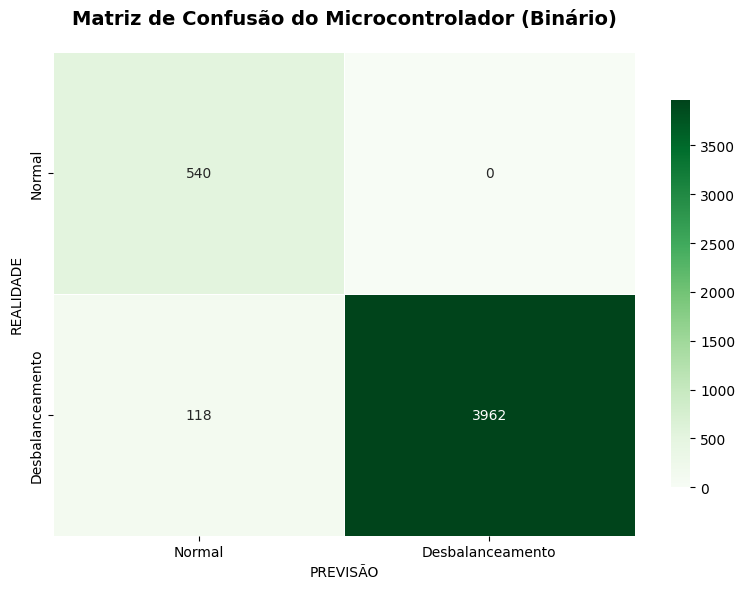


--- RELATÓRIO DO XGBOOST (O que irá para o ESP32-S3) ---
                  precision    recall  f1-score   support

          Normal       0.82      1.00      0.90       540
Desbalanceamento       1.00      0.97      0.99      4080

        accuracy                           0.97      4620
       macro avg       0.91      0.99      0.94      4620
    weighted avg       0.98      0.97      0.98      4620



In [ ]:
# =========================================================
# 3. O CÉREBRO XGBOOST (Parâmetros para C++)
# =========================================================
print(f"\n3. Montando as Árvores de Decisão ({qtd_classes} Classes)...")

modelo_xgb = xgb.XGBClassifier(
    objective='multi:softprob', # Mantido para gerar array C++ compatível
    num_class=qtd_classes,
    n_estimators=15,           # Árvore menor e mais leve para o ESP32-S3
    learning_rate=0.15,
    max_depth=4,
    num_parallel_tree=1,
    alpha=0.5,
    min_child_weight=3,
    early_stopping_rounds=10,
    base_score=0.5,
    random_state=42,
    n_jobs=-1
)



# =========================================================
# 4. TREINAMENTO
# =========================================================
print("\n🚀 Iniciando o Treinamento do XGBoost...")
modelo_xgb.fit(
    X_tr_esc, y_tr,
    sample_weight=pesos_amostras,
    eval_set=[(X_te_esc, y_te)],
    verbose=10
)

# Salva no formato nativo para posterior conversão
modelo_xgb.save_model(f'modelo_tabular_xgboost_mod{TIPO_MODELO}.json')
print(f"\n✅ XGBoost (Modo {TIPO_MODELO}) Treinado e Salvo!")

# =========================================================
# 5. AUDITORIA FINAL E MATRIZ
# =========================================================
print("\n🔎 Auditando a Árvore de Decisões...")

previsoes_prob = modelo_xgb.predict_proba(X_te_esc)
previsoes_classes = []

# O Filtro de Inércia (Limiar de Confiança)
LIMIAR_ALARME = 0.65

for prob in previsoes_prob:
    classe_vencedora = np.argmax(prob)
    certeza = prob[classe_vencedora]

    if classe_vencedora != 0 and certeza < LIMIAR_ALARME:
        previsoes_classes.append(0)
    else:
        previsoes_classes.append(classe_vencedora)

previsoes_classes = np.array(previsoes_classes)

cm = confusion_matrix(y_te, previsoes_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=nomes_classes, yticklabels=nomes_classes,
            linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Matriz de Confusão do Microcontrolador (Binário)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('REALIDADE')
plt.xlabel('PREVISÃO')
plt.tight_layout()
plt.show()

print("\n--- RELATÓRIO DO XGBOOST (O que irá para o ESP32-S3) ---")
print(classification_report(y_te, previsoes_classes, target_names=nomes_classes))

🚀 Iniciando Treinamento do XGBoost Massivo (Servidor)...
[0]	validation_0-mlogloss:0.32212
[100]	validation_0-mlogloss:0.01439
[200]	validation_0-mlogloss:0.01608
[300]	validation_0-mlogloss:0.01661
[400]	validation_0-mlogloss:0.01666
[500]	validation_0-mlogloss:0.01673
[600]	validation_0-mlogloss:0.01684
[700]	validation_0-mlogloss:0.01681
[800]	validation_0-mlogloss:0.01689
[900]	validation_0-mlogloss:0.01692
[999]	validation_0-mlogloss:0.01701

✅ Modelo XGBoost do Servidor treinado e salvo!

🔎 Auditando o XGBoost do Servidor...


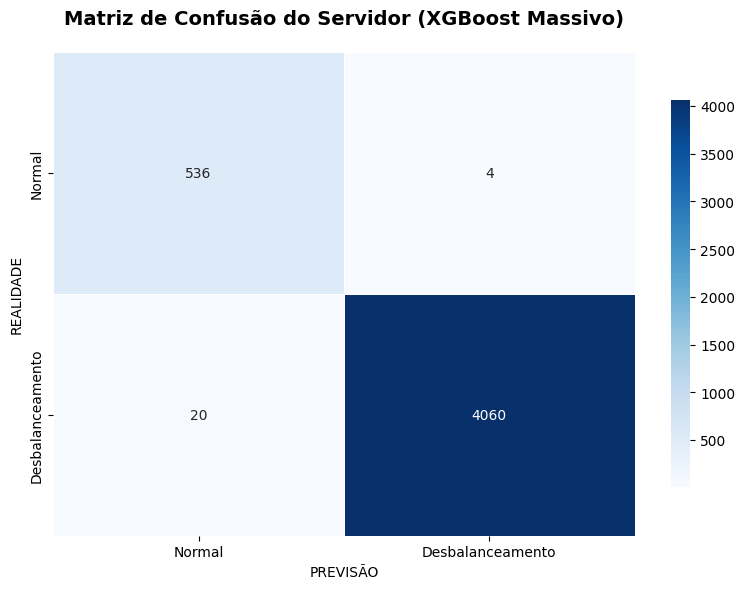


--- RELATÓRIO DO XGBOOST MASSIVO (Backend) ---
                  precision    recall  f1-score   support

          Normal       0.96      0.99      0.98       540
Desbalanceamento       1.00      1.00      1.00      4080

        accuracy                           0.99      4620
       macro avg       0.98      0.99      0.99      4620
    weighted avg       0.99      0.99      0.99      4620



In [ ]:
import joblib
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# TREINAMENTO DO MODELO PESADO (XGBOOST SERVIDOR)
# =========================================================
print("🚀 Iniciando Treinamento do XGBoost Massivo (Servidor)...")

# Sem as restrições de C++ e memória do ESP32, criamos um modelo gigantesco
modelo_servidor_xgb = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=2,
    n_estimators=1000,          # 1000 árvores! (O modelo da borda tinha apenas 15)
    learning_rate=0.05,         # Aprende devagar e com extrema precisão
    max_depth=10,               # Árvores ultra-profundas (analisam interações complexas entre variáveis)
    subsample=0.8,              # Sorteia amostras para evitar vício (overfitting)
    colsample_bytree=0.8,       # Sorteia colunas para diversificar as árvores
    random_state=42,
    n_jobs=-1                   # Usa todos os núcleos do processador do servidor
)

# Treinamento com os mesmos dados normalizados
modelo_servidor_xgb.fit(
    X_tr_esc, y_tr,
    eval_set=[(X_te_esc, y_te)],
    verbose=100                 # Mostra o progresso a cada 100 árvores
)

# Salva o arquivo pesado para ser carregado pela sua API Python no Backend
joblib.dump(modelo_servidor_xgb, 'modelo_servidor_xgboost_pesado.pkl')
print("\n✅ Modelo XGBoost do Servidor treinado e salvo!")

# =========================================================
# AUDITORIA E MATRIZ DE CONFUSÃO (SERVIDOR)
# =========================================================
print("\n🔎 Auditando o XGBoost do Servidor...")

# Lemos as probabilidades brutas (Matriz 2D)
probabilidades = modelo_servidor_xgb.predict_proba(X_te_esc)
# Extraímos apenas o índice (0 ou 1) da classe vencedora usando matemática vetorial
previsoes_servidor = np.argmax(probabilidades, axis=1)

# Visualização em tons de Azul (Blues) para diferenciar do XGBoost leve (Greens)
cm_servidor = confusion_matrix(y_te, previsoes_servidor)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_servidor, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_classes, yticklabels=nomes_classes,
            linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Matriz de Confusão do Servidor (XGBoost Massivo)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('REALIDADE')
plt.xlabel('PREVISÃO')
plt.tight_layout()
plt.show()

print("\n--- RELATÓRIO DO XGBOOST MASSIVO (Backend) ---")
print(classification_report(y_te, previsoes_servidor, target_names=nomes_classes))

# Fase 5: Análise Avançada e Auditoria de Risco

Não basta saber se o nosso modelo XGBoost acerta os diagnósticos; nós precisamos medir a **sensibilidade** dele.
Para isso usamos a **Curva ROC** (Receiver Operating Characteristic) e a métrica **AUC** (Area Under the Curve).

* **O que é a Curva ROC?** É um gráfico que mostra a troca (trade-off) entre os Verdadeiros Positivos (alarmes corretos) e Falsos Positivos (alarmes falsos).
* **O que é AUC?** É uma nota de `0.0` a `1.0`.
    * `AUC = 0.50` significa que a IA está apenas jogando cara ou coroa (Chute Aleatório).
    * `AUC = 1.00` significa que a IA consegue separar 100% perfeitamente a classe Normal do Defeito, sem nunca dar um alarme falso.
    * No mundo da metrologia industrial, buscamos sempre uma `AUC > 0.95`.


Gerando Auditoria Avançada de Performance (XGBoost)...


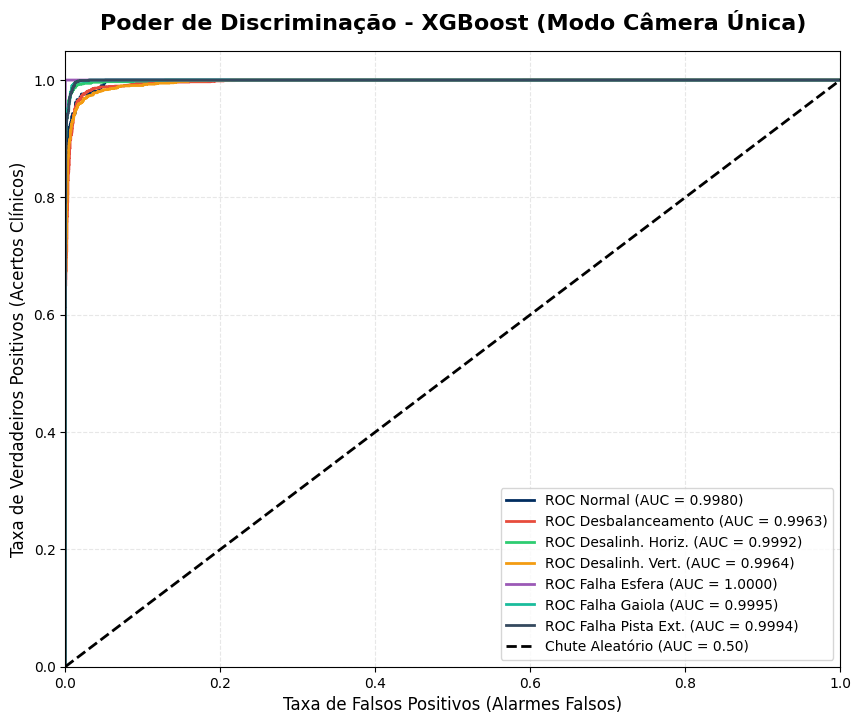

💡 Interpretação: Quanto mais a linha colorida 'abraçar' o canto superior esquerdo, mais perfeita é a IA.


In [ ]:
# ==========================================================
# 6. AVALIAÇÃO DE DISCRIMINAÇÃO: A CURVA ROC
# ==========================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

print("\nGerando Auditoria Avançada de Performance (XGBoost)...")

# Como nosso modelo prevê 7 defeitos diferentes, precisamos binarizar as respostas.
# Ex: Para a curva do Desbalanceamento, a IA pensa: "É Desbalanceamento (1) ou Qualquer Outra Coisa (0)?"
classes_unicas = np.unique(y_te)
y_binarizado = label_binarize(y_te, classes=classes_unicas)
n_classes = len(classes_unicas)

fpr = dict() # Taxa de Falso Positivo (False Positive Rate)
tpr = dict() # Taxa de Verdadeiro Positivo (True Positive Rate)
roc_auc = dict() # Área sob a curva

# Calcula a precisão isolada de cada defeito
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_binarizado[:, i], previsoes_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Renderização do Gráfico
plt.figure(figsize=(10, 8))
cores = cycle(['#002c5f', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#34495e'])

for i, color in zip(range(n_classes), cores):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC {nomes_classes[i]} (AUC = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chute Aleatório (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (Alarmes Falsos)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (Acertos Clínicos)', fontsize=12)
plt.title(f'Poder de Discriminação - XGBoost (Modo Câmera Única)', fontsize=16, fontweight='bold', pad=15)
plt.legend(loc="lower right")
plt.grid(alpha=0.3, linestyle='--')
plt.show()

print("💡 Interpretação: Quanto mais a linha colorida 'abraçar' o canto superior esquerdo, mais perfeita é a IA.")

### Passo 2: O Nível de Confiança e a Lógica de Cascata

O XGBoost não cospe apenas um diagnóstico (ex: "Desbalanceamento"). Ele entrega um Array de Probabilidades (ex: "Tenho 90% de certeza que é Desbalanceamento e 10% que é Desalinhamento").

Saber medir a "Dúvida" do algoritmo é o segredo para construir a nossa **Arquitetura em Cascata**:
* Se o microcontrolador ESP32 der o diagnóstico e tiver **certeza absoluta (> 90%)**, ele pisca o LED vermelho na fábrica e não gasta dados de internet.
* Se o XGBoost ficar **em dúvida (< 90%)**, o ESP32 compacta a Janela de Dados (Acelerômetro + Microfone) e manda por Wi-Fi para o servidor SaaS. Lá no servidor, a nossa pesada "Rede Y Multimodal" (CNN + Dense) assume o caso para dar o veredito final.

O código abaixo plota um gráfico para nos ajudar a achar o número mágico (Limiar) para configurar no nosso código C++.


Mapeando os níveis de dúvida da Inteligência Artificial...


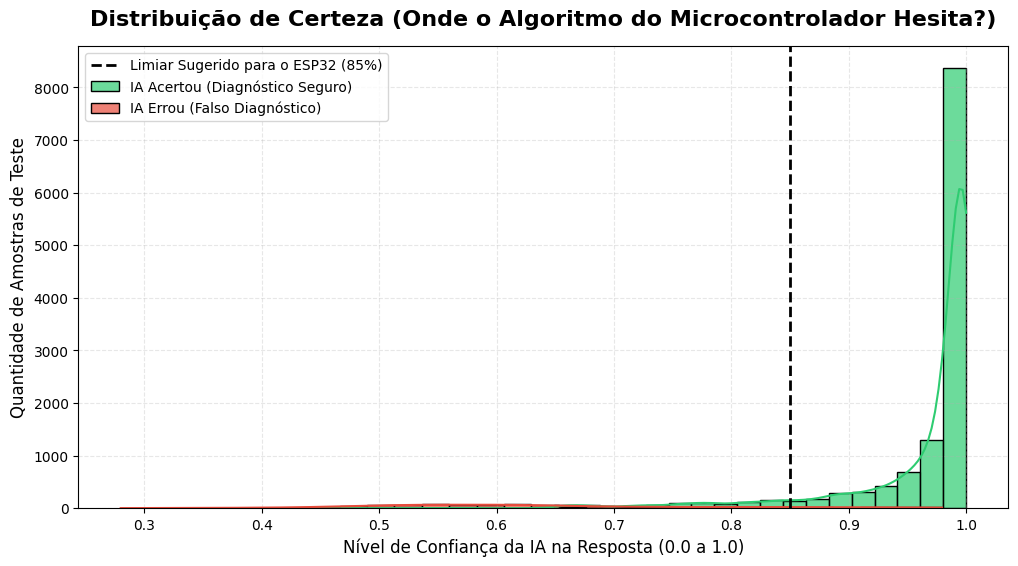


--- INSIGHTS PARA A REGRA DE NEGÓCIO DA PLACA (C++) ---
Média de confiança geral quando o modelo ACERTA: 96.54%
Média de confiança quando o XGBoost ERRA: 63.67%
Confiança MÁXIMA de um erro (O pior cenário de Falso Positivo Seguro): 97.94%

[Ação de Engenharia]: Configure o 'Threshold' do código C++ acima da média de erro para que os casos duvidosos sejam repassados ao SaaS e não gerem falso alarme na fábrica.


In [ ]:
# ==========================================================
# 7. PSICOLOGIA DA IA: DISTRIBUIÇÃO DE CONFIANÇA
# ==========================================================
print("\nMapeando os níveis de dúvida da Inteligência Artificial...")

# Pega a probabilidade máxima (O Nível de Certeza da árvore de decisão final)
confiancas = np.max(previsoes_prob, axis=1)

# Separa as previsões onde a IA acertou e onde ela errou
acertos = previsoes_classes == y_te
confianca_acertos = confiancas[acertos]
confianca_erros = confiancas[~acertos]

# [FONTE: Gráficos de Densidade - Seaborn]
plt.figure(figsize=(12, 6))

# Plota a montanha verde (As vezes em que a IA acertou)
sns.histplot(confianca_acertos, bins=30, color='#2ecc71', kde=True, label='IA Acertou (Diagnóstico Seguro)', alpha=0.7)

# Só plota a montanha vermelha (Erros) se o XGBoost tiver errado alguma coisa (o que é raro no nosso dataset!)
if len(confianca_erros) > 0:
    sns.histplot(confianca_erros, bins=30, color='#e74c3c', kde=True, label='IA Errou (Falso Diagnóstico)', alpha=0.7)

# [A DECISÃO ARQUITETURAL]
# Linha de sugestão visual de onde cortar as decisões locais do hardware
plt.axvline(0.85, color='black', linestyle='--', linewidth=2, label='Limiar Sugerido para o ESP32 (85%)')

plt.title('Distribuição de Certeza (Onde o Algoritmo do Microcontrolador Hesita?)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Nível de Confiança da IA na Resposta (0.0 a 1.0)', fontsize=12)
plt.ylabel('Quantidade de Amostras de Teste', fontsize=12)
plt.legend(loc="upper left")
plt.grid(alpha=0.3, linestyle='--')
plt.show()

# ==========================================================
# EXTRA: MÉTRICAS ESTRATÉGICAS PARA O FIRMWARE C++
# ==========================================================
print("\n--- INSIGHTS PARA A REGRA DE NEGÓCIO DA PLACA (C++) ---")
print(f"Média de confiança geral quando o modelo ACERTA: {np.mean(confianca_acertos)*100:.2f}%")

if len(confianca_erros) > 0:
    print(f"Média de confiança quando o XGBoost ERRA: {np.mean(confianca_erros)*100:.2f}%")
    print(f"Confiança MÁXIMA de um erro (O pior cenário de Falso Positivo Seguro): {np.max(confianca_erros)*100:.2f}%")
    print("\n[Ação de Engenharia]: Configure o 'Threshold' do código C++ acima da média de erro para que os casos duvidosos sejam repassados ao SaaS e não gerem falso alarme na fábrica.")
else:
    print("\n Média de confiança quando a IA ERRA: Não houve erros no lote de teste (Acurácia Perfeita)!")
    print("[Ação de Engenharia]: Você pode configurar o código C++ para atuar com Limiar de Confiança em 90%.")

In [ ]:
!pip install xgboost==1.7.6 m2cgen

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.3/200.3 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.2/92.2 kB 8.4 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0


In [ ]:
import m2cgen as m2c

print("Traduzindo o Cérebro XGBoost para C/C++ Puro...")
# Converte o modelo para código C
codigo_c = m2c.export_to_c(modelo_xgb)

# Salva em um arquivo header para o Arduino
with open("embarcado_xgboost.h", "w") as f:
    f.write(codigo_c)

print("✅ Arquivo 'embarcado_xgboost.h' gerado com sucesso! Pode baixar.")

Traduzindo o Cérebro XGBoost para C/C++ Puro...
✅ Arquivo 'embarcado_xgboost.h' gerado com sucesso! Pode baixar.


In [ ]:
import m2cgen as m2c
import re

print("Traduzindo o Cérebro XGBoost para C/C++ Puro...")
codigo_c = m2c.export_to_c(modelo_xgb)

# =========================================================
# 🛠️ A VACINA PARA O COMPILADOR DO ARDUINO (C++) 🛠️
# O m2cgen gera um "compound literal" (double[]){...} que o C++ proíbe.
# Este código caça esse padrão e substitui por atribuições limpas.
# =========================================================
codigo_c = re.sub(
    r"memcpy\(output, \(double\[\]\)\{(.+?),\s*(.+?)\},\s*2\s*\*\s*sizeof\(double\)\);",
    r"output[0] = \1;\n    output[1] = \2;",
    codigo_c
)

# Salva em um arquivo header para o Arduino
with open("embarcado_xgboost.h", "w") as f:
    f.write(codigo_c)

print("✅ Arquivo 'embarcado_xgboost.h' corrigido e gerado com sucesso! Pode baixar.")

Traduzindo o Cérebro XGBoost para C/C++ Puro...
✅ Arquivo 'embarcado_xgboost.h' corrigido e gerado com sucesso! Pode baixar.
